<a href="https://colab.research.google.com/github/MiyoBran/Alura-ONE-G9/blob/main/formacion-estadisticas-y-machine-learning-grupo9-one/07-ia-aumentada-prevision-atrasos-vuelos/EST_07_optimizaci%C3%B3n_aeroportuaria.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---

### 📚 Cheat Sheet Estadístico: Clasificación vs. Regresión

Hasta ahora, nuestro objetivo era predecir **categorías**. A partir de este proyecto de predicción de vuelos, nuestro objetivo es predecir **cantidades continuas**. Este cambio de la variable objetivo ($Y$) altera por completo las matemáticas subyacentes del modelo.

**1. La Naturaleza de la Variable Objetivo ($Y$)**

* **Clasificación (El modelo anterior):** La variable objetivo es *Discreta* (categórica).
* *Matemática:* $Y \in \{0, 1\}$ (Ej. $0$ = Cumplido, $1$ = Moroso).
* *Lógica:* El algoritmo busca trazar una **frontera de decisión** en el espacio para separar grupos.
* *Ejemplo en vuelos:* ¿El vuelo se va a retrasar? (Sí / No).


* **Regresión (El nuevo modelo):** La variable objetivo es *Continua*.
* *Matemática:* $Y \in \mathbb{R}$ (Ej. Minutos exactos de atraso, pudiendo ser $15.5$, $120.3$, etc.).
* *Lógica:* El algoritmo busca trazar una **línea o curva de mejor ajuste** que pase lo más cerca posible de todos los puntos de datos.
* *Ejemplo en vuelos:* ¿*Cuántos minutos* exactamente se va a retrasar el vuelo?



**2. La Muerte de la Matriz de Confusión**
En Clasificación, podíamos contar los "aciertos" (Verdaderos Positivos, Verdaderos Negativos) porque las opciones eran finitas.
En Regresión, **la probabilidad de adivinar el número exacto continuo es matemáticamente cero**. Si un vuelo se atrasa $14.32$ minutos, y el modelo predice $14.30$ minutos, la Matriz de Confusión diría que es un "Error" (Falso Positivo/Negativo). Sin embargo, comercialmente y estadísticamente, fallar por $0.02$ minutos es un modelo extraordinario.

**3. El Nuevo Enfoque: Análisis de Residuales (Errores)**
Como ya no podemos medir "aciertos exactos", en Regresión medimos la **Distancia** entre la predicción y la realidad. A esta diferencia se le llama *Residual* o *Error*:


$$Error = Y_{real} - Y_{predicha}$$

Para evaluar si nuestro modelo de regresión es bueno, dejaremos atrás el *Recall* y la *Precisión*, y entraremos al mundo de la Inferencia Estadística aplicada:

* **Varianza y Desviación:** Qué tan dispersos están nuestros errores.
* **Minimización de Costos:** Conectando con Análisis Matemático 1, los algoritmos de regresión utilizan **Derivadas** para encontrar el punto mínimo de una función de costo (es decir, el punto donde el error global es el más pequeño posible).

---

#**CLASE 1**

In [1]:
import pandas as pd

# datos =  pd.read_csv('/content/flights.csv')
url_original  = 'https://github.com/MiyoBran/Alura-ONE-G9/blob/main/formacion-estadisticas-y-machine-learning-grupo9-one/07-ia-aumentada-prevision-atrasos-vuelos/flights.csv'
url = url_original.replace('/github.com' , '/raw.githubusercontent.com').replace('/blob','')
datos = pd.read_csv(url)
datos.shape

(71175, 11)

In [2]:
datos.head()

,flight_id,airline,aircraft_type,schengen,origin,arrival_time,departure_time,day,year,is_holiday,delay
0,26,MM,Airbus A320,non-schengen,TCY,8.885071,10.885071,0,2010,False,70.205981
1,10,YE,Airbus A320,non-schengen,TCY,8.939996,11.939996,0,2010,False,38.484609
2,3,BZ,Embraer E175,schengen,TZF,18.635384,22.635384,0,2010,False,2.388305
3,28,BZ,Airbus A330,non-schengen,EMM,15.967963,17.967963,0,2010,False,19.138491
4,15,BZ,Airbus A330,non-schengen,FJB,16.571894,19.571894,0,2010,False,15.016271


In [3]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71175 entries, 0 to 71174
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   flight_id       71175 non-null  int64  
 1   airline         71175 non-null  object 
 2   aircraft_type   71175 non-null  object 
 3   schengen        71175 non-null  object 
 4   origin          71175 non-null  object 
 5   arrival_time    71175 non-null  float64
 6   departure_time  71175 non-null  float64
 7   day             71175 non-null  int64  
 8   year            71175 non-null  int64  
 9   is_holiday      71175 non-null  bool   
 10  delay           71175 non-null  float64
dtypes: bool(1), float64(3), int64(3), object(4)
memory usage: 5.5+ MB


In [4]:
# Solo variables numericas
datos.describe()

,flight_id,arrival_time,departure_time,day,year,delay
count,71175.000000,71175.000000,71175.000000,71175.000000,71175.000000,71175.000000
mean,15.465135,13.283159,16.480222,182.000000,2016.000000,12.548378
std,8.649646,4.023380,4.143705,105.366769,3.741684,23.125349
min,1.000000,7.065594,10.065594,0.000000,2010.000000,-41.028033
25%,8.000000,8.939996,12.668655,91.000000,2013.000000,-4.412876
50%,15.000000,14.258911,16.376052,182.000000,2016.000000,9.740454
75%,23.000000,16.909690,20.041281,273.000000,2019.000000,27.650853
max,30.000000,19.341235,23.341235,364.000000,2022.000000,125.632352


In [5]:
datos.describe(include='O')

,airline,aircraft_type,schengen,origin
count,71175,71175,71175,71175
unique,3,6,2,10
top,BZ,Airbus A320,schengen,TZF
freq,47598,30778,42569,14162


### 📊 Radiografía de la Base de Datos (Vuelos)

 `datos.describe(include='O')`: Comportamiento de las Variables Categóricas**

* Tienes **3 aerolíneas** distintas y **10 aeropuertos de origen**.
* El avión más utilizado es el **Airbus A320** y el origen más frecuente es el aeropuerto codificado como **TZF**. Estas variables categóricas son vitales, ya que en el negocio aeroportuario, el tipo de avión o el aeropuerto de salida suelen explicar gran parte de los retrasos.

---

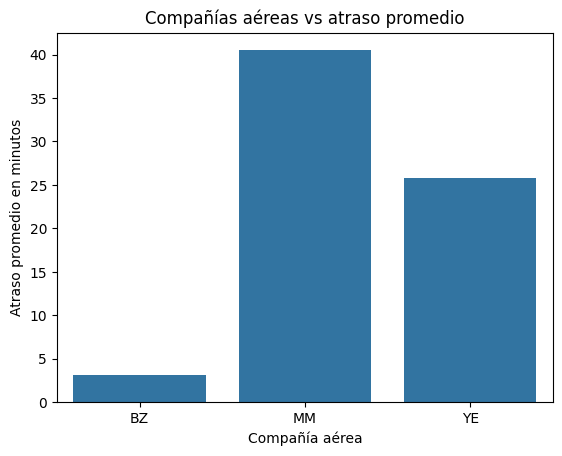

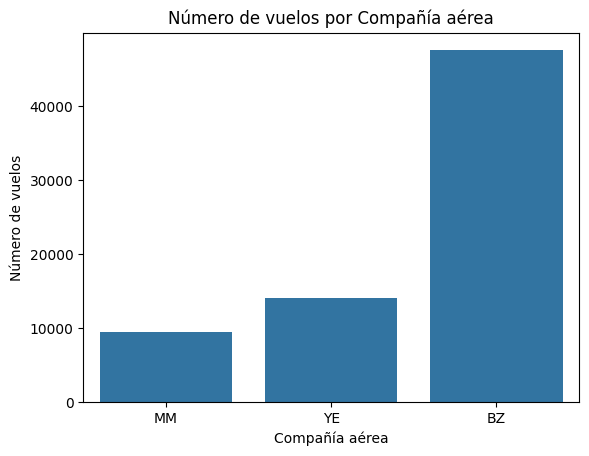

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

avg_delay = datos.groupby('airline')['delay'].mean().reset_index()
sns.barplot(x='airline',y='delay',data=avg_delay)
plt.title('Compañías aéreas vs atraso promedio')
plt.xlabel('Compañía aérea')
plt.ylabel('Atraso promedio en minutos')
plt.show()

sns.countplot(data=datos, x='airline')
plt.title('Número de vuelos por Compañía aérea')
plt.xlabel('Compañía aérea')
plt.ylabel('Número de vuelos')
plt.show()

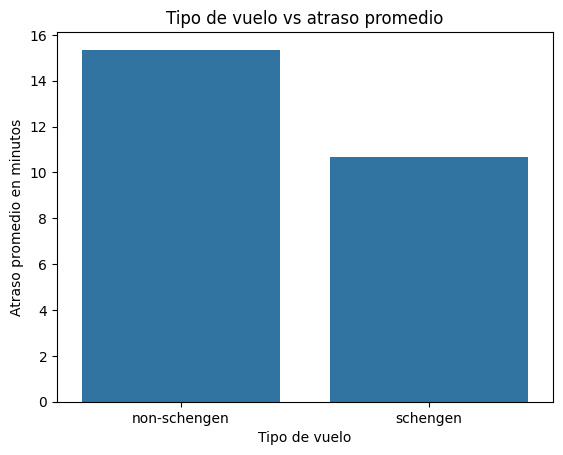

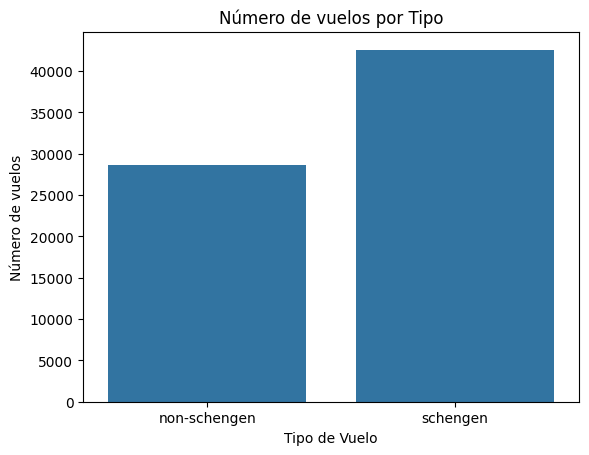

In [7]:
avg_delay = datos.groupby('schengen')['delay'].mean().reset_index()
sns.barplot(x='schengen',y='delay',data=avg_delay)
plt.title('Tipo de vuelo vs atraso promedio')
plt.xlabel('Tipo de vuelo')
plt.ylabel('Atraso promedio en minutos')
plt.show()

sns.countplot(data=datos, x='schengen')
plt.title('Número de vuelos por Tipo')
plt.xlabel('Tipo de Vuelo')
plt.ylabel('Número de vuelos')
plt.show()

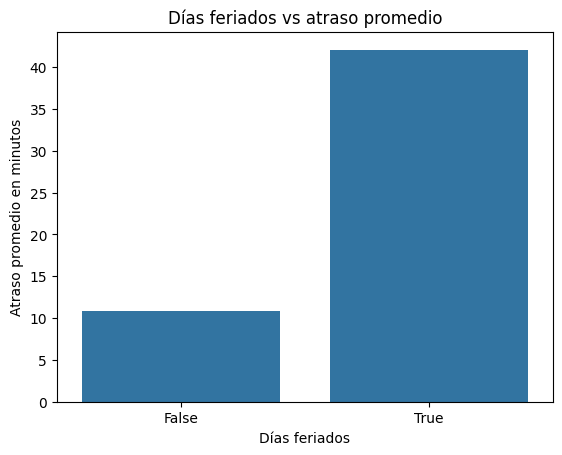

In [8]:
avg_delay = datos.groupby('is_holiday')['delay'].mean().reset_index()
sns.barplot(x='is_holiday',y='delay',data=avg_delay)
plt.title('Días feriados vs atraso promedio')
plt.xlabel('Días feriados')
plt.ylabel('Atraso promedio en minutos')
plt.show()

In [9]:
datos['aircraft_type'].value_counts().index

Index(['Airbus A320', 'Airbus A330', 'Boeing 787', 'Embraer E175',
       'Boeing 737', 'Boeing 777'],
      dtype='object', name='aircraft_type')

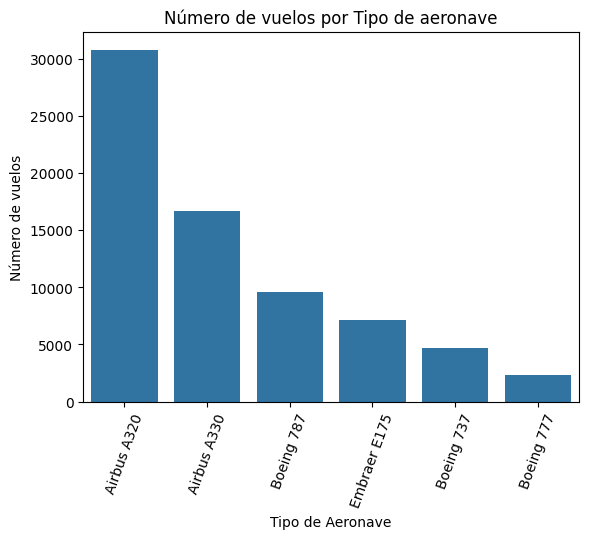

In [10]:
order = datos['aircraft_type'].value_counts().index
sns.countplot(data=datos, x='aircraft_type',order=order)
plt.title('Número de vuelos por Tipo de aeronave')
plt.xticks(rotation=70)
plt.xlabel('Tipo de Aeronave')
plt.ylabel('Número de vuelos')
plt.show()

## 💻 Script Senior: Dashboard de Exploración de Datos (EDA)

💡 HALLAZGO: La aerolínea MM es la que menos vuelos tiene, pero sufre los peores atrasos promedio (~40 min).


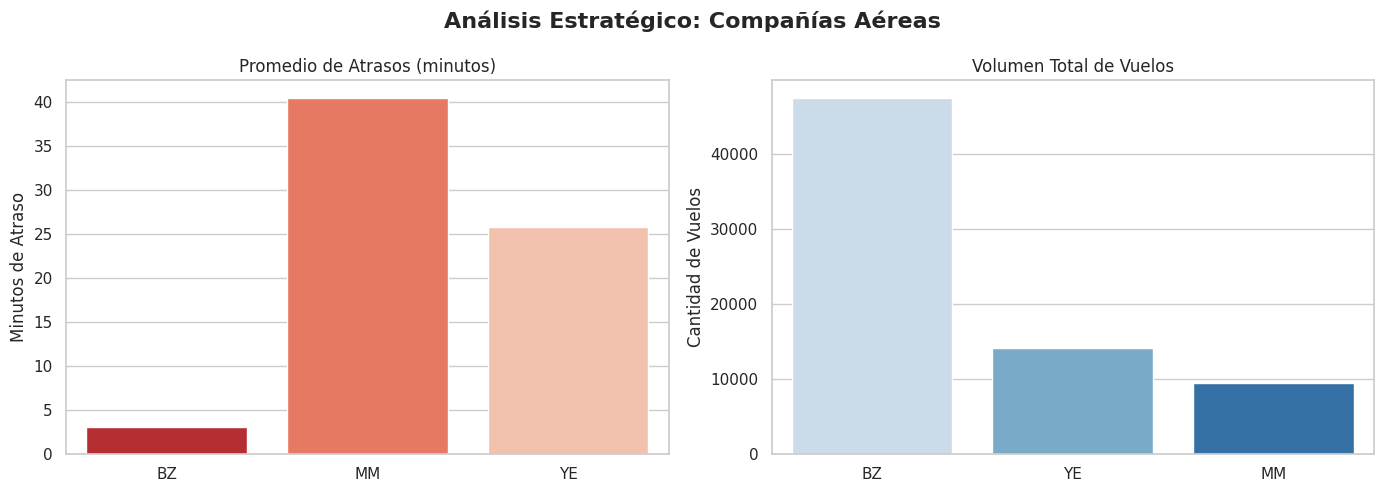

💡 HALLAZGO: Los vuelos fuera del espacio Schengen (internacionales largos) tienden a atrasarse más.


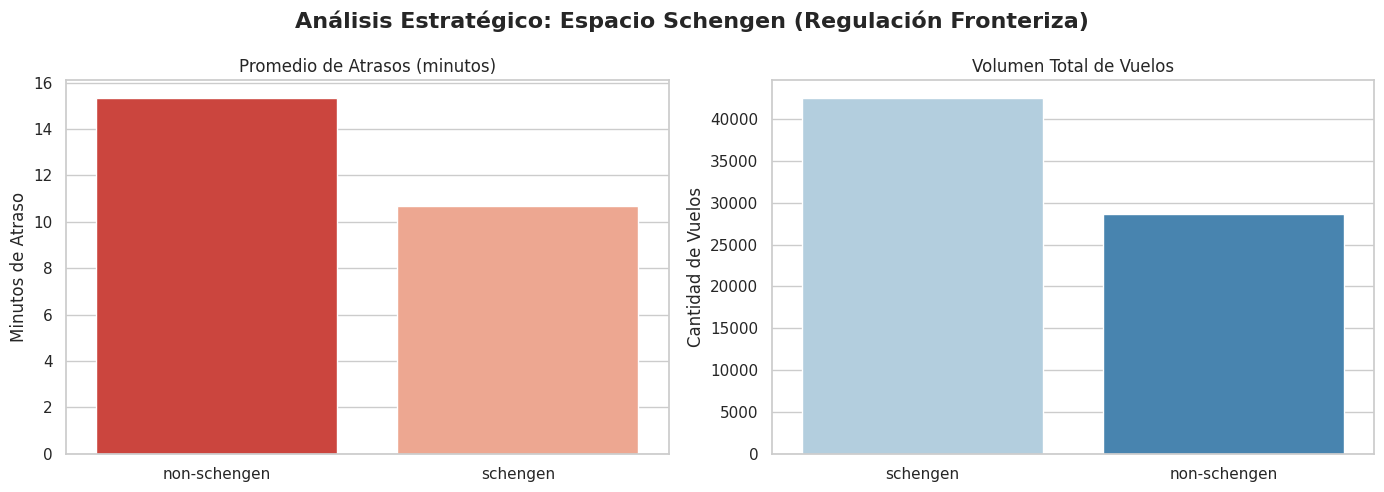

💡 HALLAZGO CRÍTICO: En días feriados, el promedio de atraso se cuadruplica (de ~10 a >40 min).


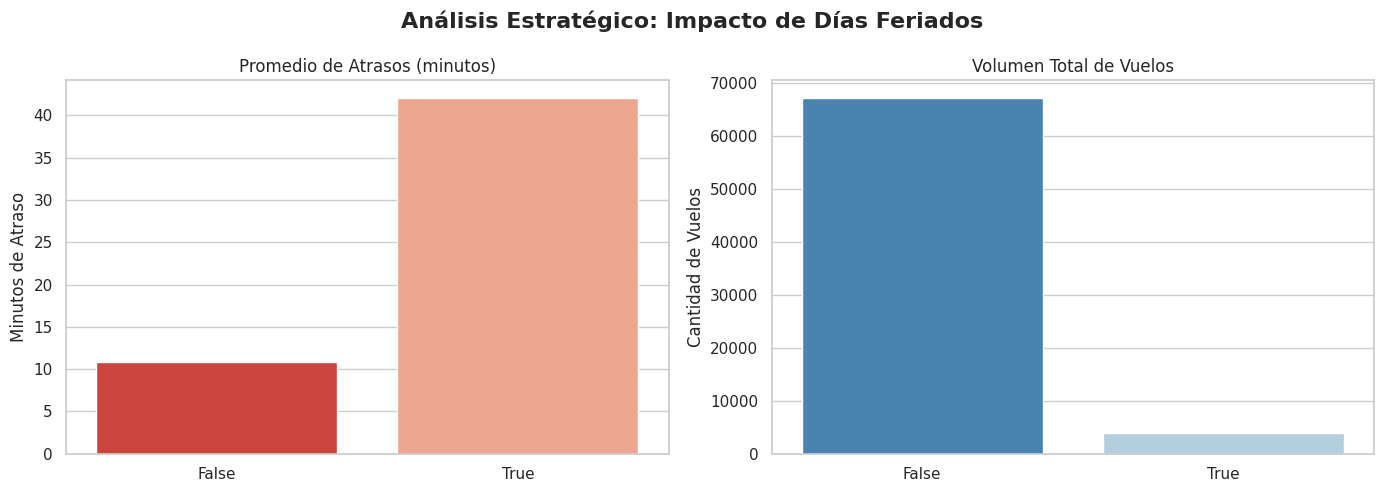

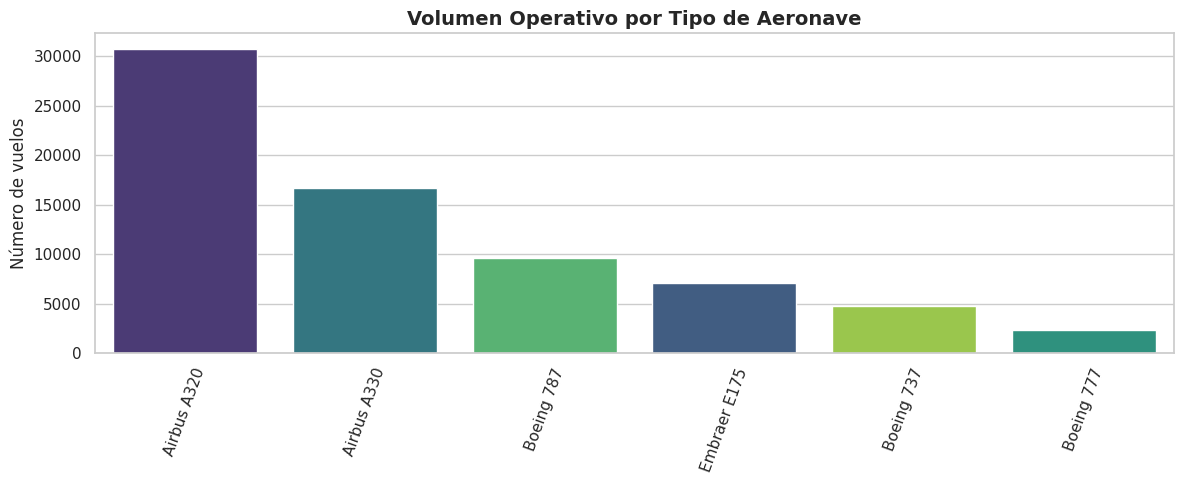

In [11]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ==============================================================================
# 1. FUNCIÓN DE VISUALIZACIÓN GERENCIAL (DASHBOARD)
# ==============================================================================
# Creamos una función reutilizable para evitar repetir código.
# Esta función grafica el Promedio de Atrasos a la izquierda y el Volumen de Vuelos a la derecha.

def plot_dashboard_comparativo(df, columna_agrupacion, titulo_general, rotacion_x=0):
    """
    Genera un panel con dos gráficos:
    1. Gráfico de barras con el promedio de atraso (delay) por categoría.
    2. Gráfico de conteo con el volumen total de vuelos por categoría.
    """
    # Configuramos el tamaño del panel (1 fila, 2 columnas)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"Análisis Estratégico: {titulo_general}", fontsize=16, fontweight='bold')

    # --- GRÁFICO 1: Atraso Promedio (Impacto Financiero/Operativo) ---
    # Calculamos el promedio agrupando por la categoría solicitada
    avg_delay = df.groupby(columna_agrupacion)['delay'].mean().reset_index()

    # FIX: Se asigna 'hue' explícitamente y se apaga la leyenda para evitar el FutureWarning
    sns.barplot(ax=axes[0], data=avg_delay, x=columna_agrupacion, y='delay',
                hue=columna_agrupacion, palette='Reds_r', legend=False)
    axes[0].set_title(f"Promedio de Atrasos (minutos)")
    axes[0].set_xlabel("")
    axes[0].set_ylabel("Minutos de Atraso")
    axes[0].tick_params(axis='x', rotation=rotacion_x)

    # --- GRÁFICO 2: Volumen de Vuelos (Frecuencia) ---
    # Ordenamos de mayor a menor frecuencia para facilitar la lectura
    orden_frecuencia = df[columna_agrupacion].value_counts().index

    # FIX: Se asigna 'hue' explícitamente y se apaga la leyenda
    sns.countplot(ax=axes[1], data=df, x=columna_agrupacion, order=orden_frecuencia,
                  hue=columna_agrupacion, palette='Blues_r', legend=False)
    axes[1].set_title(f"Volumen Total de Vuelos")
    axes[1].set_xlabel("")
    axes[1].set_ylabel("Cantidad de Vuelos")
    axes[1].tick_params(axis='x', rotation=rotacion_x)

    # Ajustamos el espaciado y mostramos el dashboard
    plt.tight_layout()
    plt.show()

# ==============================================================================
# 2. EJECUCIÓN DEL ANÁLISIS EXPLORATORIO (EDA)
# ==============================================================================
# Definimos el estilo estético general de Seaborn
sns.set_theme(style="whitegrid")

# 1. Análisis por Aerolínea
print("💡 HALLAZGO: La aerolínea MM es la que menos vuelos tiene, pero sufre los peores atrasos promedio (~40 min).")
plot_dashboard_comparativo(datos, 'airline', 'Compañías Aéreas')

# 2. Análisis por Tratado Schengen (Vuelos Internacionales vs Regionales)
print("💡 HALLAZGO: Los vuelos fuera del espacio Schengen (internacionales largos) tienden a atrasarse más.")
plot_dashboard_comparativo(datos, 'schengen', 'Espacio Schengen (Regulación Fronteriza)')

# 3. Análisis por Días Feriados
print("💡 HALLAZGO CRÍTICO: En días feriados, el promedio de atraso se cuadruplica (de ~10 a >40 min).")
plot_dashboard_comparativo(datos, 'is_holiday', 'Impacto de Días Feriados')

# 4. Análisis por Tipo de Aeronave (Solo volumen, como pidió el instructor)
plt.figure(figsize=(12, 5))
orden_aeronaves = datos['aircraft_type'].value_counts().index

# FIX: Se asigna 'hue' explícitamente y se apaga la leyenda
sns.countplot(data=datos, x='aircraft_type', order=orden_aeronaves,
              hue='aircraft_type', palette='viridis', legend=False)
plt.title("Volumen Operativo por Tipo de Aeronave", fontsize=14, fontweight='bold')
plt.xticks(rotation=70)
plt.xlabel("")
plt.ylabel("Número de vuelos")
plt.tight_layout()
plt.show()

## Freedman-Diaconis Rule

<Axes: xlabel='arrival_time', ylabel='Count'>

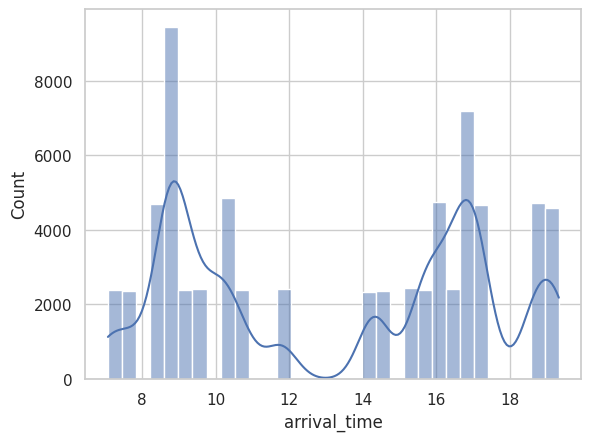

In [12]:
#Observamos nuestro histograma de frecuencias para "ver"  como estan distribuidos nuestros horarios de llegada.
sns.histplot(data=datos,x='arrival_time',kde=True)

https://en.wikipedia.org/wiki/Freedman%E2%80%93Diaconis_rule

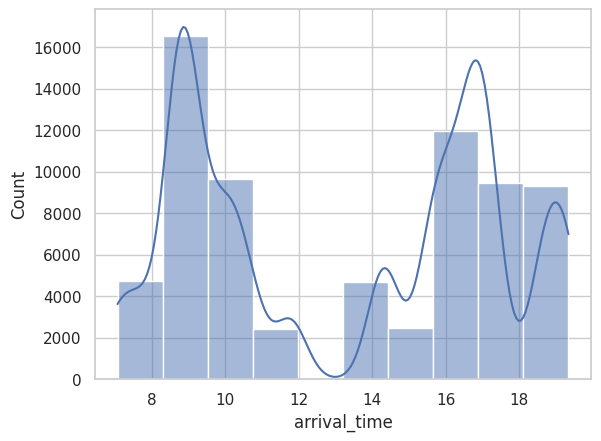

In [13]:
# Utilizamos la regla de Diaconis para determinar el "ancho" de nuestras clases
# , ya que si lo hacemos manual podemos no tener un resultado correcto.
sns.histplot(data=datos,x='arrival_time',kde=True,bins=10);

In [14]:
# Utilizamos la formula para determinar
import numpy as np

def ancho_bin(df,columna):
  q75,q25 = np.percentile(df[columna],[75,25])
  iqr = q75-q25
  ancho = 2 * iqr * np.power(len(df[columna]), -1/3)
  return ancho

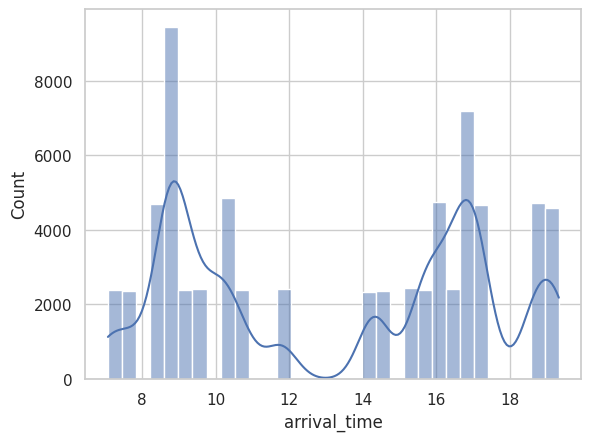

In [15]:
# realizamos el grafico con el ancho estimado con Diaconis
binwidth = ancho_bin(datos,'arrival_time')
sns.histplot(data=datos,x='arrival_time',kde=True,binwidth=binwidth);

<Axes: xlabel='departure_time', ylabel='Count'>

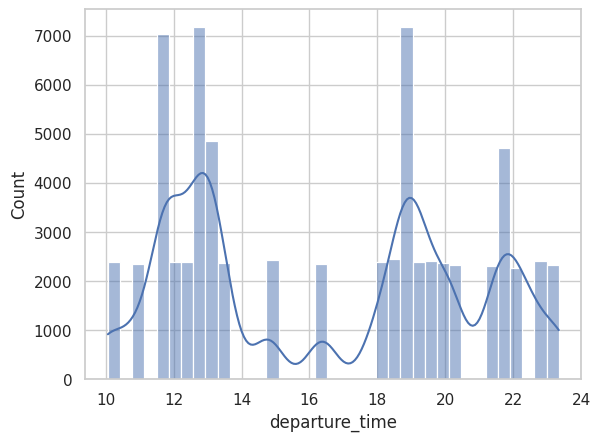

In [16]:
#Ppodemos aplicar  la misma operacion para el horario de salida.
binwidth = ancho_bin(datos,'departure_time')
sns.histplot(data=datos,x='departure_time',kde=True,binwidth=binwidth)

Para evaluar el atraso promedio (nuestra variable de respuesta) , utilizaremos la media y la mediana de la misma.

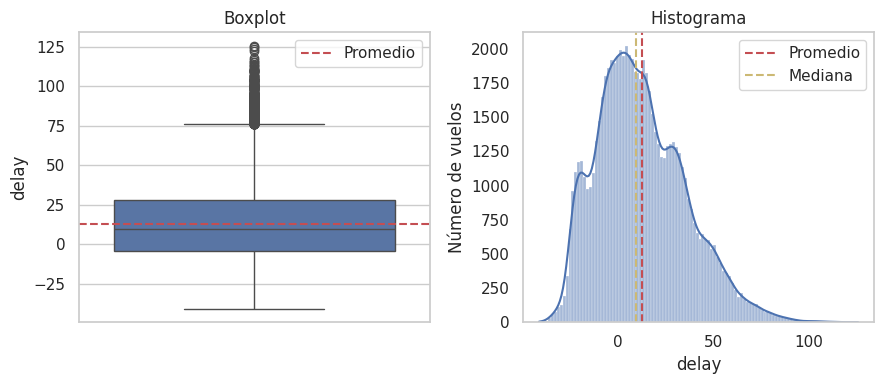

In [17]:
atraso_promedio = datos['delay'].mean()
atraso_mediana = datos['delay'].median()

# Haremos dos figuras en nuestro lienzo
fig, ax = plt.subplots(1,2,figsize=(9,4))

# Generaremos el Boxplot para conocer el rango intercuantil , y otra informacion
# estadistica de nuestros datos.
sns.boxplot(data=datos, y='delay',ax=ax[0])
ax[0].set_title('Boxplot')
# Creamos una linea horizontal para ver donde esta el promedio (la mediana se
# visualiza con el mismo boxplot)
ax[0].axhline(y=atraso_promedio, color='r', linestyle='--', label='Promedio')
ax[0].legend()

# Utilizamos la funcion que habiamos creado para determinar el ancho de los bins
binwidth = ancho_bin(datos, 'delay')

# Ahora hacemos el histograma a la derecha (ax[1]) , con linea de densidad
sns.histplot(data=datos, x='delay', ax=ax[1], kde=True, binwidth=binwidth)
plt.ylabel('Número de vuelos')
#Que no se vea la cuadricula
plt.grid(False)
ax[1].set_title('Histograma')
# Creamos dos Lineas que nos permitan visualizar  media y mediana
ax[1].axvline(x=atraso_promedio, color='r', linestyle='--', label='Promedio')
ax[1].axvline(x=atraso_mediana, color='y', linestyle='--', label='Mediana')
# que la legenda sea visible
ax[1].legend()

# para que nuestros graficos no se solapen
plt.tight_layout()

plt.show()

---

## 📚 Cheat Sheet Estadístico: Distribuciones, Diaconis y Boxplots

Cuando analizamos una variable continua (como los minutos de retraso en los vuelos o los tiempos de entrega ), necesitamos entender su forma matemática antes de intentar predecirla. Para ello usamos dos herramientas visuales y estadísticas fundamentales.

#### 1. La Regla de Freedman-Diaconis (El Histograma Perfecto)

El Histograma muestra la frecuencia de los datos dividiéndolos en "cajas" o *bins*. Si eliges la cantidad de *bins* "a ojo", cometes un error analítico grave:

* Si el *bin* es muy ancho, escondes detalles importantes (es como agrupar las ventas de tu PyME por año; no verás los picos mensuales).
* Si el *bin* es muy estrecho, solo verás ruido aleatorio (es como agrupar las ventas por minuto).

La **Regla de Freedman-Diaconis** es una fórmula matemática diseñada para calcular el ancho exacto y estadísticamente óptimo de cada *bin*, minimizando la diferencia entre el histograma y la verdadera distribución de probabilidad teórica.

* **Fórmula Matemática:**

$$Ancho = 2 \cdot \text{IQR} \cdot n^{-1/3}$$


* **Componentes:**
* $\text{IQR}$ es el Rango Intercuartílico (la dispersión central de los datos).
* $n$ es la cantidad total de observaciones. Al elevar a $-1/3$, estamos aplicando la raíz cúbica en el denominador.



#### 2. Anatomía del Boxplot (Diagrama de Caja y Bigotes)

El Boxplot es el "detector de anomalías" por excelencia en estadística descriptiva. No le importa la media (que es fácilmente engañada por valores extremos), sino que se basa en los **Cuartiles**, es decir, en la posición real de los datos ordenados.

* **La Caja Central (El Rango Intercuartílico - IQR):**
* La base de la caja es el **Q1 (Cuartil 1 o Percentil 25)**. El 25% de los datos es menor a este valor.
* El techo de la caja es el **Q3 (Cuartil 3 o Percentil 75)**.
* La caja en sí misma ($Q3 - Q1$) contiene exactamente al **50% central** de toda tu base de datos. En el negocio, esta caja representa tu "operación normal o esperada".


* **La Línea Central (La Mediana - Q2):**
* Es el punto exacto que divide los datos por la mitad (Percentil 50). Si la Mediana no está en el centro de la caja, la distribución es asimétrica (sesgada).


* **Los Bigotes (Los Límites de Control):**
* Marcan el límite estadístico de lo que consideramos "normal" antes de catalogarlo como un evento extremo.
* Se calculan matemáticamente así:
* Límite Inferior: $Q1 - 1.5 \cdot \text{IQR}$
* Límite Superior: $Q3 + 1.5 \cdot \text{IQR}$




* **Los Puntos (Outliers o Valores Atípicos):**
* Cualquier dato que caiga más allá de los bigotes se dibuja como un punto individual. En los vuelos, estos son los retrasos de 125 minutos. En tu PyME, podrían ser compras fraudulentas o entregas catastróficas. Son excepciones a la regla que tu modelo de Machine Learning sufrirá mucho para predecir.



---

#**CLASE 2**

Haremos Feature engeneering v--> por ejemplo columna fecha a partir de la columna dia y año.

In [18]:
datos.columns

Index(['flight_id', 'airline', 'aircraft_type', 'schengen', 'origin',
       'arrival_time', 'departure_time', 'day', 'year', 'is_holiday', 'delay'],
      dtype='object')

In [19]:
#Creamos nuestra columna fecha / date
datos['date'] = datos['year'].astype(str) +'-'+(datos['day']+1).astype(str)
# aprovechamos el metodo de pandas para hacer el cast a datetime , el %j
# convierte el N°(365) dia en dia+mes (12-31)
datos['date'] = pd.to_datetime(datos['date'],format='%Y-%j')
datos.tail(2)

,flight_id,airline,aircraft_type,schengen,origin,arrival_time,departure_time,day,year,is_holiday,delay,date
71173,5,BZ,Airbus A320,schengen,ZQO,9.344097,12.344097,364,2022,True,56.758844,2022-12-31
71174,29,BZ,Boeing 737,schengen,ZQO,8.591208,11.591208,364,2022,True,41.401648,2022-12-31


In [20]:
# podemos determinar tambien si es fin de semana, con el metodo dt.weekday
datos['is_weekend'] = datos['date'].dt.weekday.isin([5,6])
# tambien podemos saber el "nombre" del dia con el metodo de datetime ,
# day_name.
datos['day_name'] = datos['date'].dt.day_name()
datos.sample(5)

,flight_id,airline,aircraft_type,schengen,origin,arrival_time,departure_time,day,year,is_holiday,delay,date,is_weekend,day_name
5474,6,YE,Boeing 787,schengen,AUZ,17.033688,19.033688,364,2010,True,69.122676,2010-12-31,False,Friday
61524,8,BZ,Airbus A320,schengen,ZQO,15.729617,18.729617,86,2021,False,9.182064,2021-03-28,True,Sunday
31539,16,MM,Airbus A320,non-schengen,CSF,17.041281,20.041281,277,2015,False,46.769575,2015-10-05,False,Monday
38818,30,BZ,Embraer E175,schengen,PUA,8.923441,12.923441,32,2017,False,-8.407247,2017-02-02,False,Thursday
63818,1,BZ,Airbus A320,non-schengen,CNU,15.496519,18.496519,239,2021,False,15.605799,2021-08-28,True,Saturday


In [21]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71175 entries, 0 to 71174
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   flight_id       71175 non-null  int64         
 1   airline         71175 non-null  object        
 2   aircraft_type   71175 non-null  object        
 3   schengen        71175 non-null  object        
 4   origin          71175 non-null  object        
 5   arrival_time    71175 non-null  float64       
 6   departure_time  71175 non-null  float64       
 7   day             71175 non-null  int64         
 8   year            71175 non-null  int64         
 9   is_holiday      71175 non-null  bool          
 10  delay           71175 non-null  float64       
 11  date            71175 non-null  datetime64[ns]
 12  is_weekend      71175 non-null  bool          
 13  day_name        71175 non-null  object        
dtypes: bool(2), datetime64[ns](1), float64(3), int64(3), o

In [22]:
# Para prevenir warnings (no es buena practica , pero sirve con fines educativos
# para mantener limpio el notebook)
import warnings

warnings.filterwarnings('ignore')

In [23]:
# Cambiamos nuestros atributos que solo tienen 2 categorias , y remplazamos por
# valores numericos.
datos['schengen'] = datos['schengen'].replace({'non-schengen':0,'schengen':1})
datos['is_holiday'] = datos['is_holiday'].replace({False:0,True:1})
datos['is_weekend'] = datos['is_weekend'].replace({False:0,True:1})
datos.sample(3)

,flight_id,airline,aircraft_type,schengen,origin,arrival_time,departure_time,day,year,is_holiday,delay,date,is_weekend,day_name
18498,29,BZ,Boeing 737,1,ZQO,8.591208,11.591208,138,2013,0,11.235413,2013-05-19,1,Sunday
28718,28,BZ,Airbus A330,0,EMM,15.967963,17.967963,89,2015,0,-13.786414,2015-03-31,0,Tuesday
59678,28,BZ,Airbus A330,0,EMM,15.967963,17.967963,328,2020,0,3.809243,2020-11-24,0,Tuesday


In [24]:
# Nuestras variables que tienen categorias, o categoricas son:
categoricas = ['airline','aircraft_type','origin','day_name']
# Pandas tiene un metodo que nos permite codificar nuestras variables con ceros
# y unos , es el metodo get_dummies(). Ahora solo lo vemos -->
pd.get_dummies(data=datos,columns=categoricas, dtype=int).head()

,flight_id,schengen,arrival_time,departure_time,day,year,is_holiday,delay,date,is_weekend,...,origin_TCY,origin_TZF,origin_ZQO,day_name_Friday,day_name_Monday,day_name_Saturday,day_name_Sunday,day_name_Thursday,day_name_Tuesday,day_name_Wednesday
0,26,0,8.885071,10.885071,0,2010,0,70.205981,2010-01-01,0,...,1,0,0,1,0,0,0,0,0,0
1,10,0,8.939996,11.939996,0,2010,0,38.484609,2010-01-01,0,...,1,0,0,1,0,0,0,0,0,0
2,3,1,18.635384,22.635384,0,2010,0,2.388305,2010-01-01,0,...,0,1,0,1,0,0,0,0,0,0
3,28,0,15.967963,17.967963,0,2010,0,19.138491,2010-01-01,0,...,0,0,0,1,0,0,0,0,0,0
4,15,0,16.571894,19.571894,0,2010,0,15.016271,2010-01-01,0,...,0,0,0,1,0,0,0,0,0,0


In [25]:
# Aunque se generan muchas variables, en este punto no hay problema ,
# necesitamos "codificar" nuestras variables.
datos_codificados =pd.get_dummies(data=datos,columns=categoricas, dtype=int)
datos_codificados.sample(5)

,flight_id,schengen,arrival_time,departure_time,day,year,is_holiday,delay,date,is_weekend,...,origin_TCY,origin_TZF,origin_ZQO,day_name_Friday,day_name_Monday,day_name_Saturday,day_name_Sunday,day_name_Thursday,day_name_Tuesday,day_name_Wednesday
32546,14,1,7.708301,11.708301,344,2015,0,-14.375848,2015-12-11,0,...,0,0,1,1,0,0,0,0,0,0
40253,2,1,19.196804,22.196804,128,2017,0,2.335032,2017-05-09,0,...,0,0,1,0,0,0,0,0,1,0
42083,9,0,10.733469,12.733469,250,2017,1,8.171124,2017-09-08,0,...,0,1,0,1,0,0,0,0,0,0
41439,27,1,14.376052,16.376052,207,2017,0,-4.645347,2017-07-27,0,...,0,0,0,0,0,0,0,1,0,0
58086,2,1,19.196804,22.196804,222,2020,0,9.344896,2020-08-10,0,...,0,0,1,0,1,0,0,0,0,0


¡Entramos de lleno al territorio de la **Ingeniería de Características (Feature Engineering)**! Este es el paso donde la magia ocurre en Data Science. Un algoritmo de Machine Learning es solo una calculadora avanzada; si le entregas datos en formato texto (`"Friday"`, `"Airbus A320"`), se rompe. Tu trabajo como ingeniero es traducir el mundo real a un lenguaje matemático puro.

Vamos a analizar las decisiones técnicas que tomaste junto al instructor:

1. **Creación de Atributos (Feature Creation):**
* Transformar el "Día 100 del año 2022" en una fecha real (`datetime`) fue brillante. Nos permitió extraer características ocultas con altísimo poder predictivo para los negocios: ¿Es fin de semana? ¿Qué día exacto de la semana es? En logística y transporte, los sábados operan muy diferente a los martes.


2. **Transformación Binaria (Feature Encoding simple):**
* Convertir `True/False` y `Schengen/Non-Schengen` a `1/0` es el paso más directo. Matemática pura.


3. **One-Hot Encoding (`get_dummies`):**
* Este es un concepto crítico para tu examen. ¿Por qué no simplemente asignarle un número a cada aerolínea (ej. MM = 1, YZ = 2, BZ = 3)? Porque el modelo de Regresión asumiría falsamente que BZ "vale más" o es "el triple" que MM.
* El **One-Hot Encoding** crea una columna nueva para cada categoría (ej. `airline_MM`, `airline_YZ`) y le pone un `1` si el vuelo es de esa aerolínea y un `0` si no lo es. Así, el modelo trata a todas las aerolíneas con la misma jerarquía.

---

### 💻 Script Senior: Ingeniería y Codificación de Características (Feature Engineering)

In [26]:
import pandas as pd
import numpy as np

# ==============================================================================
# 1. CREACIÓN DE CARACTERÍSTICAS (FEATURE CREATION)
# ==============================================================================
print("--- INICIANDO INGENIERÍA DE CARACTERÍSTICAS ---")

# [Programación Defensiva] Limpiamos columnas previas si la celda se re-ejecuta
if 'date_str' in datos.columns:
    datos = datos.drop(columns=['date_str'])

# A. Reconstrucción de la variable Fecha (Datetime)
# Concatenamos Año y Día (sumando 1 porque el sistema empieza en 0)
datos['date_str'] = datos['year'].astype(str) + '-' + (datos['day'] + 1).astype(str)
# %Y = Año con 4 dígitos | %j = Día del año (001 a 366)
datos['date'] = pd.to_datetime(datos['date_str'], format='%Y-%j')
datos = datos.drop(columns=['date_str']) # Limpiamos la columna auxiliar

# B. Extracción de patrones temporales para el negocio
# dt.weekday devuelve 0=Lunes ... 5=Sábado, 6=Domingo
datos['is_weekend'] = datos['date'].dt.weekday.isin([5, 6])
datos['day_name'] = datos['date'].dt.day_name()

print("✔ Fechas reconstruidas y patrones temporales extraídos (Fines de semana y Nombres de días).")

# ==============================================================================
# 2. CODIFICACIÓN BINARIA SEGURA (ANTI-CORRUPCIÓN)
# ==============================================================================
# Usamos Idempotencia: El código verifica si la columna ya es numérica.
# Si ya lo es (porque ejecutaste la celda antes), la ignora y evita los NaN.
# Para variables con solo dos estados, usamos el mapeo directo a 1 (Positivo) y 0 (Negativo).
# En Pandas moderno, el método recomendado (y sin warnings) es map() o astype(int) para booleanos.

# Booleanos directos a Enteros
if datos['is_holiday'].dtype not in ['int32', 'int64']:
    datos['is_holiday'] = datos['is_holiday'].astype(int)

if datos['is_weekend'].dtype not in ['int32', 'int64']:
    datos['is_weekend'] = datos['is_weekend'].astype(int)

# Texto binario a Enteros mediante diccionario de mapeo
# Para texto, verificamos si el tipo sigue siendo 'O' (Object/String)
if datos['schengen'].dtype == 'O':
    diccionario_schengen = {'non-schengen': 0, 'schengen': 1}
    datos['schengen'] = datos['schengen'].map(diccionario_schengen)

print("✔ Variables binarias codificadas a 1/0 (Con protección de re-ejecución).")

# ==============================================================================
# 3. CODIFICACIÓN ONE-HOT (DUMMY VARIABLES)
# ==============================================================================
# Para variables con más de dos categorías, evitamos la jerarquía numérica creando columnas dummy.
columnas_categoricas = ['airline', 'aircraft_type', 'origin', 'day_name']

# get_dummies es seguro por naturaleza porque devuelve un DataFrame completamente nuevo
# get_dummies transforma cada categoría en una nueva columna de 1s y 0s
datos_codificados = pd.get_dummies(data=datos, columns=columnas_categoricas, dtype=int)

print(f"✔ One-Hot Encoding aplicado. El DataFrame pasó de {datos.shape[1]} a {datos_codificados.shape[1]} columnas.")
print("--- PROCESO COMPLETADO ---\n")

# Mostramos una muestra aleatoria del resultado final
display(datos_codificados.sample(5))


--- INICIANDO INGENIERÍA DE CARACTERÍSTICAS ---
✔ Fechas reconstruidas y patrones temporales extraídos (Fines de semana y Nombres de días).
✔ Variables binarias codificadas a 1/0 (Con protección de re-ejecución).
✔ One-Hot Encoding aplicado. El DataFrame pasó de 14 a 36 columnas.
--- PROCESO COMPLETADO ---



,flight_id,schengen,arrival_time,departure_time,day,year,is_holiday,delay,date,is_weekend,...,origin_TCY,origin_TZF,origin_ZQO,day_name_Friday,day_name_Monday,day_name_Saturday,day_name_Sunday,day_name_Thursday,day_name_Tuesday,day_name_Wednesday
43529,19,1,16.245220,19.245220,346,2017,0,27.569910,2017-12-13,0,...,0,1,0,0,0,0,0,0,0,1
15061,19,1,16.245220,19.245220,274,2012,0,35.465642,2012-10-01,0,...,0,1,0,0,1,0,0,0,0,0
22344,27,1,14.376052,16.376052,29,2014,0,-11.187994,2014-01-30,0,...,0,0,0,0,0,0,0,1,0,0
70090,4,1,11.781391,14.781391,292,2022,0,-16.122545,2022-10-20,0,...,1,0,0,0,0,0,0,1,0,0
46734,17,0,16.718722,21.718722,195,2018,0,4.710285,2018-07-15,1,...,0,0,0,0,0,0,1,0,0,0


In [27]:
# Vamos a visualizar la correlacion entre horario de llegada y salida *-->
# Observamos que es practicamente 1 , por lo que deberiamos elegir solo 1 de las
# dos.
datos[['arrival_time','departure_time']].corr()

,arrival_time,departure_time
arrival_time,1.000000,0.973797
departure_time,0.973797,1.000000


In [28]:
# Aqui obsrvamos que hay varios atributos que podriamos eliminar (por ejemplo
# los que utilizamos para determinar luego si era weekend , o el flight id que
# no nos suma nada.)
datos_codificados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71175 entries, 0 to 71174
Data columns (total 36 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   flight_id                   71175 non-null  int64         
 1   schengen                    71175 non-null  int64         
 2   arrival_time                71175 non-null  float64       
 3   departure_time              71175 non-null  float64       
 4   day                         71175 non-null  int64         
 5   year                        71175 non-null  int64         
 6   is_holiday                  71175 non-null  int64         
 7   delay                       71175 non-null  float64       
 8   date                        71175 non-null  datetime64[ns]
 9   is_weekend                  71175 non-null  int64         
 10  airline_BZ                  71175 non-null  int64         
 11  airline_MM                  71175 non-null  int64     

In [29]:
# procedemos a eliminar las que no "nos suman" en nuestro modelo.
df = datos_codificados.drop(columns=['flight_id','departure_time','day','year','date'])
df.sample(10)

,schengen,arrival_time,is_holiday,delay,is_weekend,airline_BZ,airline_MM,airline_YE,aircraft_type_Airbus A320,aircraft_type_Airbus A330,...,origin_TCY,origin_TZF,origin_ZQO,day_name_Friday,day_name_Monday,day_name_Saturday,day_name_Sunday,day_name_Thursday,day_name_Tuesday,day_name_Wednesday
67338,0,15.967963,0,-16.815606,0,1,0,0,0,1,...,0,0,0,0,0,0,0,0,0,1
32885,1,11.781391,0,-11.170102,1,1,0,0,0,1,...,1,0,0,0,0,0,1,0,0,0
46464,1,7.065594,1,50.098372,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
58379,1,9.344097,0,-12.973327,1,1,0,0,1,0,...,0,0,1,0,0,1,0,0,0,0
27657,0,16.571894,0,-10.354046,0,1,0,0,0,1,...,0,0,0,0,1,0,0,0,0,0
51808,1,18.635384,0,4.479904,0,1,0,0,0,0,...,0,1,0,0,0,0,0,0,1,0
47751,0,8.939996,0,9.518163,0,0,0,1,1,0,...,1,0,0,1,0,0,0,0,0,0
27428,0,10.733469,0,-16.629081,1,1,0,0,0,1,...,0,1,0,0,0,0,1,0,0,0
1338,1,11.781391,0,-19.947003,0,1,0,0,0,1,...,1,0,0,0,0,0,0,0,0,1
61807,1,15.729617,0,17.360158,0,1,0,0,1,0,...,0,0,1,1,0,0,0,0,0,0


---

### 📚 Cheat Sheet Estadístico: Correlación y la Trampa de la Multicolinealidad

Para predecir una variable continua $Y$ (minutos de atraso), el algoritmo de Regresión evalúa el peso o impacto de cada variable independiente $X$ (día, aerolínea, horario). Pero antes de modelar, debemos asegurar que nuestras variables $X$ sean verdaderamente "independientes" entre sí.

#### 1. El Coeficiente de Correlación de Pearson ($r$)

Es una métrica matemática que evalúa cómo se mueven dos variables juntas. Su valor siempre oscila en el intervalo $[-1, 1]$.

* **Correlación Positiva ($r \to 1$):** Ambas variables crecen juntas.
* *Ejemplo de negocio:* Inversión en Marketing ($X$) y Volumen de Ventas ($Y$).
* *En nuestro dataset:* Horario de Salida y Horario de Llegada ($r \approx 1$). Si el avión sale más tarde, llega más tarde.


* **Correlación Negativa ($r \to -1$):** Son inversamente proporcionales. Una crece, la otra cae.
* *Ejemplo de negocio:* Aumento en la Tasa de Interés ($X$) y Solicitudes de Crédito ($Y$).


* **Correlación Nula ($r \approx 0$):** No existe relación lineal; el movimiento de una no afecta a la otra.

#### 2. La Trampa de la Multicolinealidad

Ocurre cuando dos o más variables independientes ($X_1, X_2$) están altamente correlacionadas entre sí (como `arrival_time` y `departure_time`).

* **El Problema Matemático:** En Cálculo y Álgebra Lineal, la Regresión busca aislar el efecto individual de cada variable usando derivadas parciales. Si $X_1$ y $X_2$ son casi idénticas, la matriz matemática se vuelve inestable (inversión de matrices singulares). El algoritmo entra en cortocircuito porque no puede decidir a cuál de las dos variables asignarle el "peso" del retraso.
* **La Analogía de Ventas:** Imagina a dos vendedores que *siempre* visitan a los mismos clientes juntos y cierran una venta de $100,000. Como gerente, es matemáticamente imposible saber qué porcentaje de la venta fue mérito del Vendedor A y cuánto del Vendedor B. Para medir el rendimiento real, debes separarlos (eliminar a uno del modelo).

#### 3. Selección de Características (Feature Selection)

Purgar el "ruido" es tan importante como conservar las variables útiles. Eliminamos columnas por dos motivos de peso:

1. **Redundancia (Multicolinealidad):** Eliminamos `departure_time` porque `arrival_time` ya nos cuenta exactamente la misma historia.
2. **Falta de Causalidad:** Eliminamos `flight_id` porque un número de ticket no causa matemáticamente un retraso. Eliminamos `date`, `day` y `year` porque ya extrajimos su "jugo analítico" (si es feriado, fin de semana, etc.). Mantener las fechas crudas solo confunde al modelo, a menos que estemos haciendo un análisis estricto de Series Temporales.

---

In [30]:
# ==============================================================================
# 1. AUDITORÍA DE MULTICOLINEALIDAD (CORRELACIÓN REDUNDANTE)
# ==============================================================================
print("--- DETECCIÓN DE MULTICOLINEALIDAD ---")
# Evaluamos matemáticamente qué tan parecidas son ambas variables
correlacion_vuelos = datos_codificados[['arrival_time', 'departure_time']].corr()
display(correlacion_vuelos)

print("\n💡 CONCLUSIÓN ESTADÍSTICA:")
print("La correlación es casi perfecta (1.0). Esto indica que ambas columnas")
print("aportan exactamente la misma información. Conservar ambas genera 'ruido'")
print("en los algoritmos de regresión. Eliminaremos 'departure_time'.")

# ==============================================================================
# 2. SELECCIÓN DE CARACTERÍSTICAS (FEATURE SELECTION)
# ==============================================================================
# Definimos la lista negra de columnas a purgar por falta de valor predictivo:
# - flight_id: Es un identificador arbitrario, no un patrón matemático.
# - departure_time: Purgada por multicolinealidad.
# - day, year, date: Ya extrajimos su jugo analítico (feriados, fines de semana, etc.).
columnas_basura = ['flight_id', 'departure_time', 'day', 'year', 'date']

# Ejecutamos la purga y creamos el DataFrame definitivo para el modelo
df_limpio = datos_codificados.drop(columns=columnas_basura)

print("\n--- LIMPIEZA DE DATOS COMPLETADA ---")
print(f"El dataset pasó de {datos_codificados.shape[1]} a {df_limpio.shape[1]} columnas analíticas puras.")

# Inspeccionamos la matriz final lista para Scikit-Learn
display(df_limpio.sample(5))

--- DETECCIÓN DE MULTICOLINEALIDAD ---


,arrival_time,departure_time
arrival_time,1.000000,0.973797
departure_time,0.973797,1.000000



💡 CONCLUSIÓN ESTADÍSTICA:
La correlación es casi perfecta (1.0). Esto indica que ambas columnas
aportan exactamente la misma información. Conservar ambas genera 'ruido'
en los algoritmos de regresión. Eliminaremos 'departure_time'.

--- LIMPIEZA DE DATOS COMPLETADA ---
El dataset pasó de 36 a 31 columnas analíticas puras.


,schengen,arrival_time,is_holiday,delay,is_weekend,airline_BZ,airline_MM,airline_YE,aircraft_type_Airbus A320,aircraft_type_Airbus A330,...,origin_TCY,origin_TZF,origin_ZQO,day_name_Friday,day_name_Monday,day_name_Saturday,day_name_Sunday,day_name_Thursday,day_name_Tuesday,day_name_Wednesday
55690,0,16.571894,0,7.296805,0,1,0,0,0,1,...,0,0,0,0,0,0,0,0,1,0
49241,1,18.801235,0,7.112191,1,0,0,1,0,0,...,1,0,0,0,0,1,0,0,0,0
17276,0,8.794147,0,30.071813,0,0,0,1,1,0,...,0,0,0,0,0,0,0,0,1,0
68579,0,19.341235,1,38.807628,0,1,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
52426,1,18.635384,1,14.273962,0,1,0,0,0,0,...,0,1,0,0,0,0,0,0,1,0


---

### 📚 Cheat Sheet MLOps: `get_dummies` vs. `OneHotEncoder`

**1. El Problema de Pandas (`get_dummies`) en Producción:**
Imagina que hoy entrenas tu modelo y Pandas crea la columna `aerolinea_MM` porque vio vuelos de esa empresa. Mañana, tu software recibe un nuevo lote de datos diarios para predecir, pero *casualmente* ese día la aerolínea "MM" no tuvo vuelos. Pandas **no creará** la columna `aerolinea_MM`. Tu modelo de Machine Learning, que fue entrenado para recibir 20 columnas, de repente recibe 19 y el sistema sufre un *Crash* (falla catastrófica).

**2. La Solución de Scikit-Learn (`OneHotEncoder`):**
Scikit-Learn está diseñado para crear "tuberías" (Pipelines).

* **Memoria (`fit`):** Cuando usas `OneHotEncoder`, este "aprende" y memoriza todas las categorías exactas que existen durante el entrenamiento.
* **Tolerancia a Fallos (`handle_unknown='ignore'`):** Si mañana en producción llega una aerolínea nueva que el modelo nunca vio, o si falta una, el codificador no colapsa. Simplemente rellena con ceros o ignora el dato desconocido, garantizando que la estructura matemática (la cantidad exacta de columnas) sea siempre idéntica.
* **El Orquestador (`make_column_transformer`):** Es un director de orquesta. Le dice al código: *"Aplica el OneHotEncoder solo a estas 4 columnas de texto, y a las demás (las numéricas como delay o arrival_time) déjalas pasar intactas (`remainder='passthrough'`)"*.

---

### 💻 Script Senior: Pipeline de Preparación End-to-End (MLOps)

Arranca desde la descarga web, aplica la ingeniería de características, limpia la multicolinealidad y finalmente orquesta la codificación con Scikit-Learn, todo bajo un nuevo DataFrame llamado `df_mlops`.


In [31]:

import pandas as pd
import numpy as np
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder

# ==============================================================================
# 1. INGESTA DE DATOS (DATA INGESTION)
# ==============================================================================
print("1. Descargando datos desde el repositorio...")
url_original = 'https://github.com/MiyoBran/Alura-ONE-G9/blob/main/formacion-estadisticas-y-machine-learning-grupo9-one/07-ia-aumentada-prevision-atrasos-vuelos/flights.csv'
url = url_original.replace('/github.com' , '/raw.githubusercontent.com').replace('/blob','')
df_mlops = pd.read_csv(url)

# ==============================================================================
# 2. INGENIERÍA DE CARACTERÍSTICAS (FEATURE ENGINEERING)
# ==============================================================================
print("2. Creando variables temporales y mapeos binarios...")
# Fechas
df_mlops['date_str'] = df_mlops['year'].astype(str) + '-' + (df_mlops['day'] + 1).astype(str)
df_mlops['date'] = pd.to_datetime(df_mlops['date_str'], format='%Y-%j')
df_mlops['day_name'] = df_mlops['date'].dt.day_name()

# Binarios (1 y 0)
df_mlops['is_weekend'] = df_mlops['date'].dt.weekday.isin([5, 6]).astype(int)
df_mlops['is_holiday'] = df_mlops['is_holiday'].astype(int)
df_mlops['schengen'] = df_mlops['schengen'].map({'non-schengen': 0, 'schengen': 1})

# ==============================================================================
# 3. PURGA DE RUIDO Y MULTICOLINEALIDAD (FEATURE SELECTION)
# ==============================================================================
print("3. Eliminando columnas redundantes y ruido matemático...")
columnas_basura = ['flight_id', 'departure_time', 'day', 'year', 'date', 'date_str']
df_mlops = df_mlops.drop(columns=columnas_basura)

# ==============================================================================
# 4. ORQUESTACIÓN MLOPS (ONE-HOT ENCODING CON SCIKIT-LEARN)
# ==============================================================================
print("4. Transformando categorías con ColumnTransformer de Scikit-Learn...")
categoricas = ['airline', 'aircraft_type', 'origin', 'day_name']

# Configuramos el transformador
# sparse_output=False asegura que devuelva una matriz densa compatible con Pandas
transformador = make_column_transformer(
    (OneHotEncoder(handle_unknown='ignore', sparse_output=False), categoricas),
    remainder='passthrough'
)

# Ajustamos (aprende las categorías) y transformamos los datos en un solo paso
matriz_transformada = transformador.fit_transform(df_mlops)

# Scikit-Learn devuelve una matriz de Numpy. La reconvertimos a un DataFrame legible
nombres_columnas_finales = transformador.get_feature_names_out()
df_mlops_final = pd.DataFrame(matriz_transformada, columns=nombres_columnas_finales)

print("\n--- PIPELINE COMPLETADO EXITOSAMENTE ---")
print(f"Estructura final: {df_mlops_final.shape[0]} filas x {df_mlops_final.shape[1]} columnas.\n")

# Mostramos el resultado
display(df_mlops_final.head())


1. Descargando datos desde el repositorio...
2. Creando variables temporales y mapeos binarios...
3. Eliminando columnas redundantes y ruido matemático...
4. Transformando categorías con ColumnTransformer de Scikit-Learn...

--- PIPELINE COMPLETADO EXITOSAMENTE ---
Estructura final: 71175 filas x 31 columnas.



,onehotencoder__airline_BZ,onehotencoder__airline_MM,onehotencoder__airline_YE,onehotencoder__aircraft_type_Airbus A320,onehotencoder__aircraft_type_Airbus A330,onehotencoder__aircraft_type_Boeing 737,onehotencoder__aircraft_type_Boeing 777,onehotencoder__aircraft_type_Boeing 787,onehotencoder__aircraft_type_Embraer E175,onehotencoder__origin_AUZ,...,onehotencoder__day_name_Saturday,onehotencoder__day_name_Sunday,onehotencoder__day_name_Thursday,onehotencoder__day_name_Tuesday,onehotencoder__day_name_Wednesday,remainder__schengen,remainder__arrival_time,remainder__is_holiday,remainder__delay,remainder__is_weekend
0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,8.885071,0.0,70.205981,0.0
1,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,8.939996,0.0,38.484609,0.0
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,18.635384,0.0,2.388305,0.0
3,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,15.967963,0.0,19.138491,0.0
4,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,16.571894,0.0,15.016271,0.0


#**CLASE 3**

https://scikit-learn.org/stable/

In [32]:
# Crearemos una baseline , modelo base a partir del cual medimos nuestro
# rendimiento y evaluamos la mejora, usaremos de scikit-learn el dummyregressor
# , como asi tambien el train_test_split para dividir en prueba-entrenamiento
# nuestro dataframe.
from sklearn.dummy import DummyRegressor
from sklearn.model_selection import train_test_split
#X es todo menos nuestra variable de respuesta
X = df.drop(['delay'],axis=1)
# y es nuestra variable de respuesta
y = df['delay']

#segregamos nuestro modelo.
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3,random_state=42)

#creamos nuestro DummyRegressor
baseline = DummyRegressor()
baseline.fit(X_train,y_train)

DummyRegressor()

In [33]:
# Utilizaremos metodos/metricas para evaluar el rendimiento
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# le pedimos que haga la prediccion con datos que nunca vio
y_pred_dummy = baseline.predict(X_test)

#creamos nuestra funcion que evalua el rendimiento
def calcular_regresion(y_test,y_pred):
  # Root (mean squared error) , aun lo tenemos al cuadrado aqui
  rmse = mean_squared_error(y_test,y_pred)

  # Error absoluto promedio
  mae= mean_absolute_error(y_test,y_pred)

  r2 = r2_score(y_test,y_pred)
  # Creamos nuestro diccionario de metricas
  metricas = {
      # El error cuadrado medio , queremos que nos de el valor sin elevar al cuadrado (no minutos al cuadrado)
      'RMSE':round(rmse**(1/2),4),
      'MAE': round(mae,4),
      #El coeficiente de determinacion nos indica que tanto las variables independientes logran explicar la variable de respuesta.
      'R2': round(r2,4)
  }
  return metricas

In [34]:
resultados_baseline = calcular_regresion(y_test, y_pred_dummy)
# Este modelo tiene un r2 de 0 , el modelo no predice en nada los datos que no conoce
resultados_baseline

{'RMSE': 23.1612, 'MAE': 18.5646, 'R2': -0.0}

---

## Para saber más: métricas utilizadas en regresión

Durante el video, se presentaron algunas de las métricas más comunes para evaluar modelos de regresión, como **RMSE, MAE y R2**.

Junto con estas métricas, existen diversas otras que pueden ser bastante útiles durante la evaluación de un modelo de regresión. A continuación, podrás encontrar algunas de las métricas más utilizadas y sus traducciones en español:

- **Mean Squared Error - MSE** (Error Cuadrático Medio)
- **Mean Absolute Error - MAE** (Error Absoluto Medio)
- **Root Mean Squared Error - RMSE** (Raíz Cuadrada del Error Cuadrático Medio)
- **Mean Squared Logarithmic Error - MSLE** (Error Logarítmico Cuadrático Medio)
- **Mean Absolute Percentage Error - MAPE** (Porcentaje del Error Absoluto Medio)

---

## Mean Squared Error - MSE

El **Mean Squared Error (MSE)**, o **Error Cuadrático Medio**, es una métrica ampliamente utilizada para evaluar el rendimiento de un modelo de aprendizaje automático. Esta métrica calcula la media de los errores cuadrados, donde cada error es la diferencia entre el valor previsto por el modelo y el valor real.

La elevación al cuadrado da mayor peso a los errores mayores, lo que puede ser útil cuando esos errores son particularmente indeseables. El MSE se define matemáticamente como:

> $$MSE = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2$$
>
> Aquí, **n** denota el número de muestras, **yᵢ** representa los valores reales, **ŷᵢ** es el valor previsto y el símbolo **Σ** indica la suma de **i = 1 a n** de las diferencias cuadradas entre los valores reales y previstos.

En esta fórmula:
- **n** representa el número de observaciones o muestras
- **yᵢ** es el valor real de la i-ésima observación
- **ŷᵢ** es el valor predicho para la i-ésima observación

El MSE se calcula tomando la diferencia entre los valores reales y los valores predichos, elevando al cuadrado, sumando todas estas diferencias al cuadrado y, a continuación, dividiendo por el número de observaciones **n**.

Para evaluar la calidad de un modelo usando el MSE, **cuanto más cerca de 0 esté el valor del MSE, mejor estará el modelo en predecir los valores deseados**. Esto se debe a que un MSE de **0** indica que no hay diferencia entre los valores previstos y los valores reales, es decir, el modelo está haciendo predicciones perfectas.

Aunque el MSE es una métrica útil, vale la pena mencionar que tiene la desventaja de **dar más peso a los outliers** debido al cuadrado de cada término. Esto puede ser indeseable en muchos casos, llevando a los investigadores a usar alternativas, como el **error absoluto medio (MAE)**.

📖 [Documentación scikit-learn: mean_squared_error](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.mean_squared_error.html)

---

## Mean Absolute Error - MAE

El **Error Absoluto Medio (MAE)** es una medida de error común utilizada en modelos de regresión. Se calcula tomando la media de los valores absolutos de los errores. En otras palabras, para cada punto de datos:

1. Calculamos el error (la diferencia entre el valor predicho y el valor real).
2. Tomamos el valor absoluto de ese error (para asegurar que todos los errores sean positivos).
3. Calculamos la media de todos estos errores absolutos.

El MAE se define como:

> $$MAE = \frac{1}{n}\sum_{i=1}^{n}|y_i - \hat{y}_i|$$
>
> En esta ecuación: **Σ** representa la suma de todos los valores de **1 a n**, **n** es el número total de muestras, **yᵢ** simboliza el valor real de los datos y **ŷᵢ** representa el valor previsto.

En esta ecuación:
- **n** representa el número de observaciones o muestras
- **yᵢ** es el valor real de la i-ésima observación
- **ŷᵢ** es el valor predicho para la i-ésima observación

El MAE se calcula tomando la diferencia absoluta entre los valores reales y los valores predichos para todas las observaciones, sumando estas diferencias absolutas y, a continuación, dividiendo por el número de observaciones **n**.

El MAE es similar a la métrica del **Error Cuadrático Medio (MSE)**, pero en lugar de elevar los errores al cuadrado, simplemente toma el **valor absoluto** de los errores. Esto hace que el MAE sea **menos sensible a outliers** que el MSE, ya que los errores grandes no se amplifican por el cuadrado.

Al evaluar modelos de regresión con el MAE, **un valor menor indica un modelo más preciso**. En otras palabras, cuanto menor sea el MAE, mejor será el modelo en predecir el valor correcto para nuevos datos. El MAE tiene un límite inferior de **0**, que indica un modelo perfecto (es decir, todas las predicciones son exactas).

Cabe destacar que, aunque el MAE es una métrica útil, **no debe ser la única métrica utilizada para evaluar el rendimiento de un modelo de regresión**. Otras métricas, como el **MSE**, el **RMSE** y el **Coeficiente de Determinación (R²)**, también deben ser consideradas para obtener una evaluación completa de la capacidad de un modelo para hacer predicciones precisas.

📖 [Documentación scikit-learn: mean_absolute_error](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.mean_absolute_error.html)

---

## Root Mean Squared Error - RMSE

La **Raíz Cuadrada del Error Cuadrático Medio (RMSE)** es una métrica de evaluación comúnmente utilizada en modelos de regresión, que es esencialmente **la raíz cuadrada del MSE**.

El RMSE se calcula tomando la raíz cuadrada de la media de los errores cuadrados, que son las diferencias entre los valores previstos y los valores reales, elevadas al cuadrado. Matemáticamente se define como:

> $$RMSE = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}$$

Donde:
- **n** es el número de muestras
- **Ŷⱼ** es la predicción del modelo para la muestra j
- **Yⱼ** es el valor real para la muestra j

El RMSE es una medida de la **dispersión de los residuos (errores de predicción)** y, al igual que el MSE, penaliza los errores mayores de forma más severa que los errores menores, debido al hecho de elevar al cuadrado las diferencias. Esto lo hace particularmente sensible a grandes errores.

Un **valor menor de RMSE indica un mejor ajuste del modelo a los datos**, es decir, las predicciones del modelo están más cerca de los valores reales. Es importante resaltar que, aunque el RMSE es una métrica útil, no debe ser la única métrica considerada al evaluar la calidad de un modelo de regresión.

📖 [Documentación scikit-learn: mean_squared_error](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.mean_squared_error.html#sklearn.metrics.mean_squared_error)

---

## Mean Squared Logarithmic Error - MSLE

El **Error Logarítmico Cuadrático Medio (MSLE)** es una métrica de evaluación utilizada en problemas de predicción donde la escala de los valores objetivo o de las predicciones varía significativamente y los errores relativos son más importantes que los errores absolutos.

El MSLE mide el error cuadrático medio entre **los logaritmos naturales de los valores reales y los logaritmos naturales de las predicciones**. Matemáticamente:

$$MSLE = \frac{1}{n}\sum_{i=1}^{n}\left(\log(1+y_i) - \log(1+\hat{y}_i)\right)^2$$

Donde:
- **n** representa el número de observaciones o muestras
- **yᵢ** es el valor real de la i-ésima observación
- **ŷᵢ** es el valor predicho para la i-ésima observación

El principal punto de enfoque de esta métrica es **medir la diferencia relativa entre los valores esperados y los predichos por el modelo**, es decir, verifica la diferencia porcentual entre ellos. De modo que, pequeñas diferencias entre valores pequeños son tratadas igualmente a grandes diferencias entre valores grandes, a diferencia de lo que ocurre en el MSE, como se muestra en el siguiente ejemplo:

| Valores verdaderos | Valores Predichos | MSE | MSLE |
|---|---|---|---|
| 50 | 40 | 100.0 | 0.047634 |
| 50000 | 40000 | 100000000.0 | 0.049790 |

Esto nos muestra que las grandes diferencias entre los valores reales y predichos **tienen poca variación en el resultado final de la métrica**. Por lo tanto, esta métrica se utiliza más cuando no deseamos que grandes errores sean significativamente más penalizados que errores pequeños.

📖 [Documentación scikit-learn: mean_squared_log_error](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.mean_squared_log_error.html#sklearn.metrics.mean_squared_log_error)

---

## Mean Absolute Percentage Error - MAPE

El **Mean Absolute Percentage Error (MAPE)** es muy similar al **MAE**, con la diferencia de que mide la precisión **como un porcentaje** y puede ser calculado como el porcentaje del MAE para cada muestra. Se utiliza mucho en problemas de regresión porque proporciona una interpretación bastante intuitiva sobre el error relativo.

$$MAPE = \frac{1}{n}\sum_{i=1}^{n}\left|\frac{y_i - \hat{y}_i}{y_i}\right| \times 100\%$$

Donde:
- **n** representa el número de observaciones o muestras
- **yᵢ** es el valor real de la i-ésima observación
- **ŷᵢ** es el valor predicho para la i-ésima observación

El resultado se multiplica por **100%** para expresar el error como un porcentaje. El MAPE se utiliza frecuentemente como una métrica de error para evaluar la precisión de las predicciones en problemas de predicción y se expresa como **el porcentaje del error medio absoluto en relación con los valores reales**.

📖 [Documentación scikit-learn: mean_absolute_percentage_error](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.mean_absolute_percentage_error.html#sklearn.metrics.mean_absolute_percentage_error)

## 🎯 Desafío Oficial: Explorando Estrategias Base (El Piso de Rendimiento)

**El Contexto:** En la clase establecimos nuestra primera Línea Base (Baseline) utilizando el algoritmo `DummyRegressor` con su estrategia por defecto: adivinar siempre el promedio (`mean`).

> **La Consigna:** La [documentación de Scikit-Learn](https://scikit-learn.org/stable/modules/generated/sklearn.dummy.DummyRegressor.html) ofrece otras heurísticas simples. El desafío consiste en iterar y evaluar matemáticamente el rendimiento de este modelo "tonto" utilizando estrategias alternativas: la Mediana (`median`), el primer Cuartil (`quantile` al 0.25) y una predicción Constante (`constant` de 10.0 minutos).


 **Lógica de Negocio:** En el mundo real, implementar un modelo de Inteligencia Artificial cuesta tiempo y dinero. Antes de invertir en él, debemos preguntarnos: *"¿Qué pasaría si simplemente aplicamos una regla estúpida, como asumir que todos los vuelos/entregas se atrasan exactamente 10 minutos siempre?"*.
> Las métricas obtenidas (MAE, RMSE, $R^2$) de estas reglas básicas formarán nuestro **Piso de Rendimiento Absoluto**. Si nuestro futuro algoritmo de Machine Learning no logra superar el puntaje de esta métrica "tonta", significa que la IA no le está aportando ningún valor real a la empresa.

---
Además, aquí tenemos un desafío técnico oculto: como usamos el `ColumnTransformer` de Scikit-Learn en el paso anterior, nuestra variable objetivo ya no se llama simplemente `delay`, sino que heredó el prefijo de trazabilidad y ahora se llama `remainder__delay`.

Hemos nombrado a la función `auditar_rendimiento_regresion` y hemos utilizado `np.sqrt()` para calcular la raíz cuadrada del error, evadiendo así el error de versiones obsoletas (`squared=False`) que sufrió el instructor en el video.
---

### 💻 Script Senior: Evaluador Universal y Línea Base (Baseline)

In [35]:

import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ==============================================================================
# 1. FUNCIÓN AUDITORA DE REGRESIÓN (EL TERMOSTATO DEL NEGOCIO)
# ==============================================================================
def auditar_rendimiento_regresion(y_verdadera, y_predicha):
    """
    Evalúa matemáticamente qué tan lejos están las predicciones de la realidad.
    Devuelve un diccionario con las métricas financieras/estadísticas clave.
    """
    # Usamos np.sqrt para evitar problemas de compatibilidad con versiones de sklearn
    rmse = np.sqrt(mean_squared_error(y_verdadera, y_predicha))
    mae = mean_absolute_error(y_verdadera, y_predicha)
    r2 = r2_score(y_verdadera, y_predicha)

    return {
        'RMSE (Castiga errores graves)': round(rmse, 4),
        'MAE (Error promedio en minutos)': round(mae, 4),
        'R2 Score (Poder predictivo)': round(r2, 4)
    }

# ==============================================================================
# 2. SEGREGACIÓN DE DATOS (EL SIMULADOR DE LA REALIDAD)
# ==============================================================================
print("--- INICIANDO PROTOCOLO DE LÍNEA BASE (BASELINE) ---")

# Separamos las variables predictoras (X) de la variable objetivo (y)
# Nota: Usamos el nombre exacto que le asignó nuestro Pipeline MLOps
X = df_mlops_final.drop(columns=['remainder__delay'])
y = df_mlops_final['remainder__delay']

# Cuarentena del 30% de los datos para el examen final
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
print(f"✔ Datos divididos: {X_train.shape[0]} vuelos para entrenar, {X_test.shape[0]} para auditar.\n")

# ==============================================================================
# 3. PRUEBA DE ESTRATEGIAS "TONTAS" (EL DESAFÍO)
# ==============================================================================
# Evaluamos diferentes heurísticas básicas para saber cuál es el mínimo a superar
estrategias_base = ["mean", "median", ("quantile", 0.25), ("constant", 10.0)]

print("--- RESULTADOS DE LA AUDITORÍA (SIN INTELIGENCIA ARTIFICIAL) ---")

for estrategia in estrategias_base:
    # Desempaquetamos la tupla si la estrategia requiere un valor adicional (cuantiles o constantes)
    if isinstance(estrategia, tuple):
        nombre_est, valor = estrategia
        if nombre_est == "quantile":
            modelo_tonto = DummyRegressor(strategy=nombre_est, quantile=valor)
        else:
            modelo_tonto = DummyRegressor(strategy=nombre_est, constant=valor)
        etiqueta_print = f"{nombre_est} ({valor})"
    else:
        modelo_tonto = DummyRegressor(strategy=estrategia)
        etiqueta_print = estrategia

    # Entrenamos el modelo tonto y predecimos
    modelo_tonto.fit(X_train, y_train)
    y_pred_dummy = modelo_tonto.predict(X_test)

    # Evaluamos con nuestra función Senior
    metricas = auditar_rendimiento_regresion(y_test, y_pred_dummy)

    # Imprimimos el reporte gerencial
    print(f"▶ Estrategia Baseline: {etiqueta_print.upper()}")
    for metrica, resultado in metricas.items():
        print(f"  {metrica}: {resultado}")
    print("-" * 55)

--- INICIANDO PROTOCOLO DE LÍNEA BASE (BASELINE) ---
✔ Datos divididos: 49822 vuelos para entrenar, 21353 para auditar.

--- RESULTADOS DE LA AUDITORÍA (SIN INTELIGENCIA ARTIFICIAL) ---
▶ Estrategia Baseline: MEAN
  RMSE (Castiga errores graves): 23.1612
  MAE (Error promedio en minutos): 18.5646
  R2 Score (Poder predictivo): -0.0
-------------------------------------------------------
▶ Estrategia Baseline: MEDIAN
  RMSE (Castiga errores graves): 23.3446
  MAE (Error promedio en minutos): 18.4452
  R2 Score (Poder predictivo): -0.0159
-------------------------------------------------------
▶ Estrategia Baseline: QUANTILE (0.25)
  RMSE (Castiga errores graves): 28.7554
  MAE (Error promedio en minutos): 22.0248
  R2 Score (Poder predictivo): -0.5414
-------------------------------------------------------
▶ Estrategia Baseline: CONSTANT (10.0)
  RMSE (Castiga errores graves): 23.3079
  MAE (Error promedio en minutos): 18.4449
  R2 Score (Poder predictivo): -0.0127
---------------------

---

### 💼 Interpretación Gerencial de los Resultados

Al ejecutar esto, notarás algo fascinante que conecta directamente con el desarrollo de tu proyecto "Gestión PyME Inteligente":

* **El R2 Score es negativo o cero:** Un $R^2$ de 0 significa que el modelo es literalmente una calculadora sacando el promedio. Si el $R^2$ es negativo (como verás en las estrategias `quantile` o `median`), significa que la heurística es **peor** que simplemente adivinar el promedio.
* **El MAE (Error Absoluto Medio):** Verás que ronda los 18.5 minutos. Este es nuestro "Piso". Si le pagamos el sueldo a un Ingeniero de Datos para que construya una IA, esa IA **debe** equivocarse por menos de 18 minutos. Si no, estaríamos perdiendo dinero en tecnología inútil.

## Utilizando Random Forest Regressor

In [36]:
from sklearn.ensemble import RandomForestRegressor

# En principio nuestro random forest solo necesita el parametro de prof maxima ,
# y mantenemos el mismo numero de pseudoaleatoriedad que veniamos usando por
# consistencia y repetibilidad.
modelo = RandomForestRegressor(max_depth=5, random_state=42)
#Entrenamos
modelo.fit(X_train,y_train)
# le mostramos valores q nunca vio
ypred = modelo.predict(X_test)
#utilizamos nuestra funcion para obtener las metricas
resultados_rf = calcular_regresion(y_test,ypred)
resultados_rf

{'RMSE': 13.7479, 'MAE': 11.0262, 'R2': 0.6477}

1. Yellowbrick y el prediction error plot:
> https://www.scikit-yb.org/es/latest/api/regressor/peplot.html

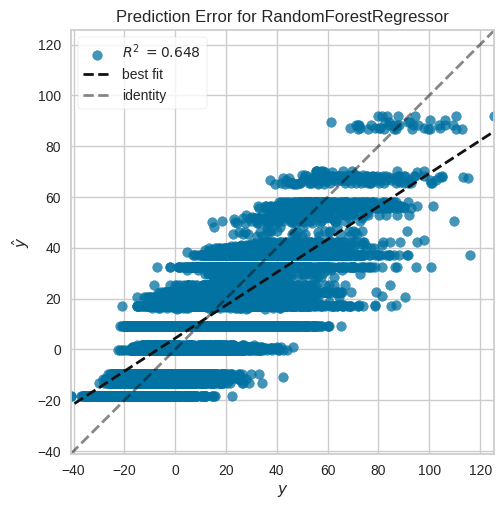

In [37]:
# Para visualizar utiliza
from yellowbrick.regressor import prediction_error

# El visualizador de errores de predicción , solo le pasamos el modelo y los datos.
visualizer = prediction_error(modelo, X_train, y_train, X_test, y_test);

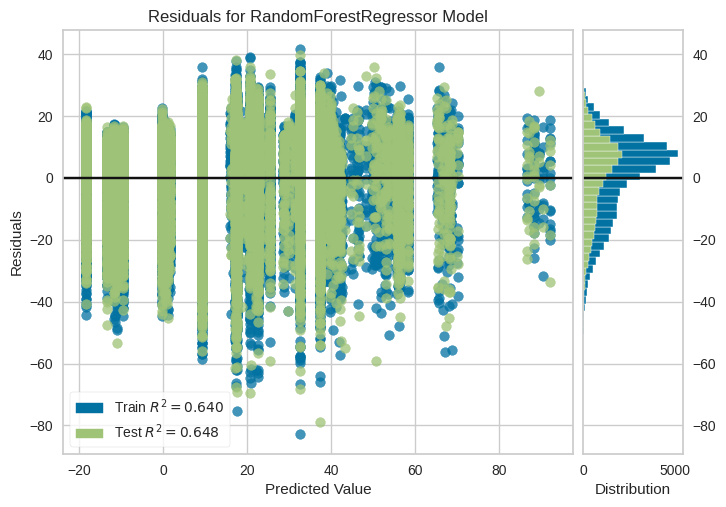

In [38]:
from yellowbrick.regressor import residuals_plot
# Tambien tenemos un plot que nos permite ver los residuos
viz = residuals_plot(modelo, X_train, y_train, X_test, y_test);

1. KFold --> https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.KFold.html
2. Cross-Validation -->
https://scikit-learn.org/stable/modules/cross_validation.html

In [39]:
from sklearn.model_selection import KFold, cross_validate
#realizremos la validacion cruzada , utilizando kfold y cross_validate.
# Definimos un diccionario , pero , los recursos de validacion cruzada de
# Scikit-learn, requieren que utilicemos una función de utilidad. Una función
# de utilidad significa que mientras mayor sea el error calculado, mejor será
# nuestro modelo.
# En los puntajes anteriores, utilizábamos funciones de costo, donde mientras
# menor el error, mejor el modelo. Aquí queremos maximizar el error, por eso
# utilizamos la versión negativa: neg_root_mean_squared_error.
scoring = {
    'RMSE':'neg_root_mean_squared_error',
    'MAE':'neg_mean_absolute_error',
    'R2':'r2'
}

cv = KFold(n_splits=5,shuffle=True, random_state=42)
cv_results = cross_validate(modelo, X_train, y_train, scoring=scoring, cv=cv)
cv_results

{'fit_time': array([3.09355426, 3.11246252, 3.28808618, 4.03784537, 3.07534099]),
 'score_time': array([0.05659556, 0.0580833 , 0.07694602, 0.06389189, 0.06705379]),
 'test_RMSE': array([-13.76989748, -13.86928373, -13.96807668, -13.85347402,
        -13.98953528]),
 'test_MAE': array([-11.03252135, -11.13534968, -11.2094657 , -11.14503717,
        -11.25775565]),
 'test_R2': array([0.64559466, 0.63745663, 0.63523823, 0.64089302, 0.63441267])}

---

### 📚 Cheat Sheet Estadístico: Random Forest, Residuos y Validación Cruzada

**1. El Concepto de Random Forest (Bosques Aleatorios)**
Hasta ahora, conocías el Árbol de Decisión simple. El problema de un solo árbol es que tiende a memorizar los datos (*Overfitting*).
En el mundo de los negocios, si tienes que tomar una decisión financiera crítica, no le preguntas a un solo analista; reúnes a un comité de 100 expertos, les das información ligeramente distinta a cada uno, y promedias sus respuestas. Eso es exactamente un **Random Forest**: un método de *Ensamble* (Ensemble). Construye múltiples árboles de decisión paralelos y promedia sus predicciones para reducir la varianza y aumentar la precisión.

**2. Análisis de Residuos (La Auditoría del Error)**
En regresión, el "Residuo" es la diferencia matemática entre la realidad y tu predicción:


$$Residuo = Y_{real} - Y_{predicho}$$


Un modelo perfecto tendría todos sus residuos en cero. Visualizar esto con la biblioteca **Yellowbrick** nos permite ver si nuestro modelo tiene sesgos sistémicos. Si los residuos forman un patrón claro (como un embudo o una curva), significa que el modelo es deficiente. Si parecen una nube de puntos aleatoria alrededor del cero (ruido blanco), ¡el modelo está extrayendo toda la información útil!

**3. La Función de Utilidad Negativa en Scikit-Learn**
Durante la Validación Cruzada (K-Fold), evaluarás tu modelo en múltiples "exámenes" (pliegues). Scikit-Learn tiene una regla interna estricta: **los algoritmos de optimización siempre buscan "Maximizar" el puntaje**.

* Si mides Precisión (Clasificación), maximizar de 0.8 a 0.9 es excelente.
* Si mides Error (Regresión), maximizar de 10 a 20 minutos es catastrófico.
Para solucionar esta contradicción matemática sin reescribir su código interno, Scikit-Learn exige que los errores se pasen como valores negativos (`neg_root_mean_squared_error`). Así, maximizar un error de -20 para que llegue a -10 significa matemáticamente acercarse al cero (minimizar el error real).

---

Utiliza la función `auditar_rendimiento_regresion` que creamos en el paso anterior y estructura la validación cruzada para que la gerencia pueda leerla fácilmente:

---

### 💻 Script Senior: Random Forest y Auditoría Visual (Yellowbrick)


--- ENTRENANDO BOSQUE ALEATORIO (RANDOM FOREST) ---
▶ Resultados del Random Forest (Prueba Única):
  RMSE (Castiga errores graves): 13.7479
  MAE (Error promedio en minutos): 11.0262
  R2 Score (Poder predictivo): 0.6477
-------------------------------------------------------

Generando gráficos de diagnóstico visual...


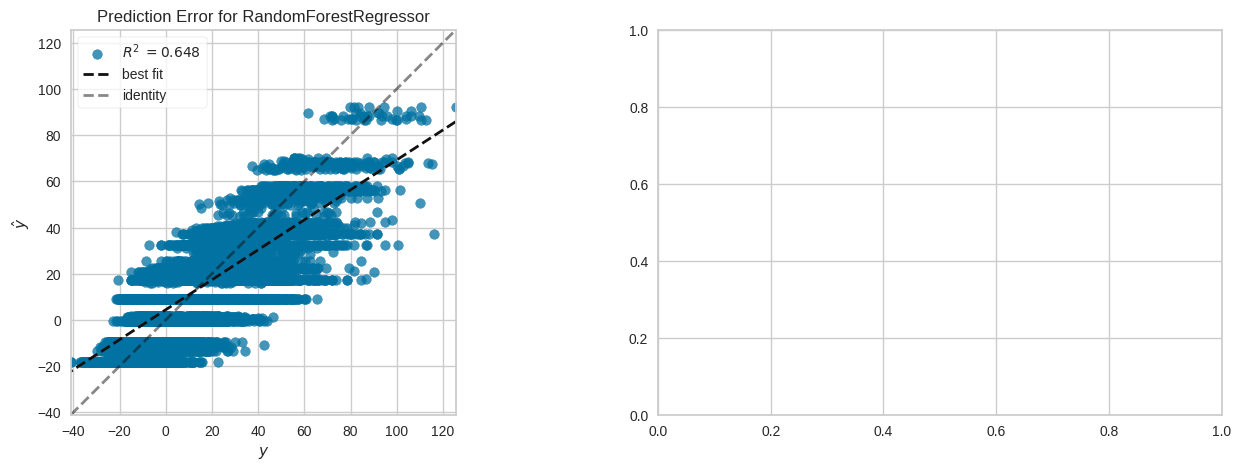

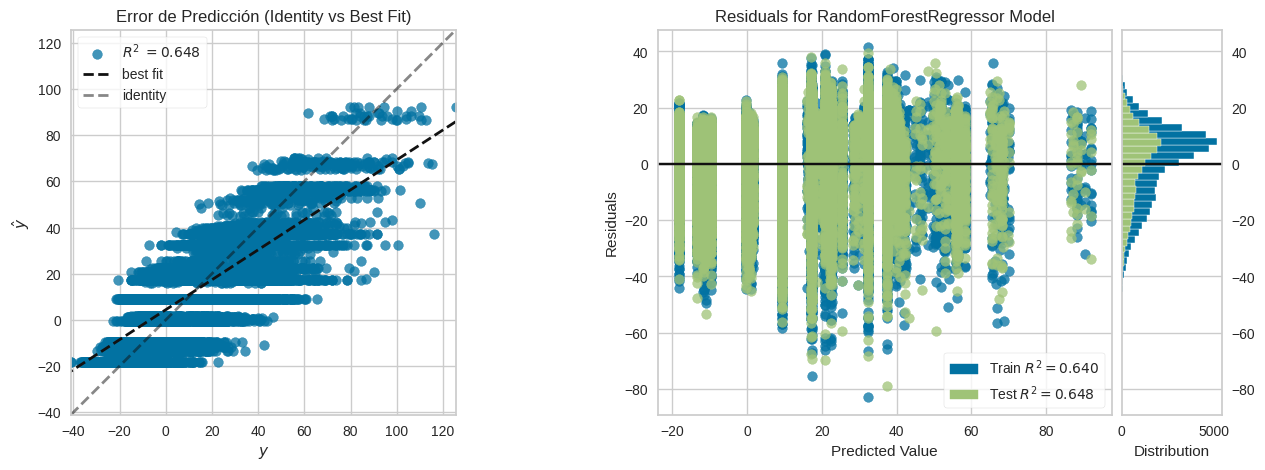

<Figure size 800x550 with 0 Axes>


--- INICIANDO PRUEBA DE ESTRÉS (K-FOLD CROSS VALIDATION) ---
▶ Consistencia del Modelo en 5 Simulaciones Diferentes:
  RMSE Promedio: 13.8901 minutos (± 0.0802)
  MAE Promedio:  11.1560 minutos (± 0.0762)
  R2 Promedio:   0.6387 (± 0.0041)
-------------------------------------------------------


In [40]:

from sklearn.ensemble import RandomForestRegressor
from yellowbrick.regressor import prediction_error, residuals_plot
from sklearn.model_selection import KFold, cross_validate
import numpy as np
import matplotlib.pyplot as plt

# ==============================================================================
# 1. ENTRENAMIENTO DEL MODELO INTELIGENTE (RANDOM FOREST)
# ==============================================================================
print("--- ENTRENANDO BOSQUE ALEATORIO (RANDOM FOREST) ---")

# Instanciamos el modelo con una profundidad máxima de 5 para evitar sobreajuste inicial
modelo_rf = RandomForestRegressor(max_depth=5, random_state=42)

# El comité de árboles aprende de los datos históricos
modelo_rf.fit(X_train, y_train)

# Predecimos sobre el conjunto de prueba (simulación del mundo real)
y_pred_rf = modelo_rf.predict(X_test)

# Evaluamos con nuestra función Senior (creada en la celda del Baseline)
resultados_rf = auditar_rendimiento_regresion(y_test, y_pred_rf)

print("▶ Resultados del Random Forest (Prueba Única):")
for metrica, valor in resultados_rf.items():
    print(f"  {metrica}: {valor}")
print("-" * 55)

# ==============================================================================
# 2. AUDITORÍA VISUAL GERENCIAL (YELLOWBRICK)
# ==============================================================================
print("\nGenerando gráficos de diagnóstico visual...")

# Creamos una figura con dos subgráficos para mantener el notebook limpio
fig, ax = plt.subplots(1, 2, figsize=(16, 5))

# Gráfico 1: Error de Predicción (La línea ideal vs. Nuestro modelo)
# La línea gris representa la identidad (predicción perfecta). La negra es el ajuste real.
prediction_error(modelo_rf, X_train, y_train, X_test, y_test, ax=ax[0])
ax[0].set_title("Error de Predicción (Identity vs Best Fit)")

# Gráfico 2: Residuos (El ruido que el modelo no pudo explicar)
# Buscamos una distribución aleatoria sin patrones evidentes.
residuals_plot(modelo_rf, X_train, y_train, X_test, y_test, ax=ax[1])
ax[1].set_title("Análisis de Residuos (Dispersión del Error)")

plt.tight_layout()
plt.show()

# ==============================================================================
# 3. PRUEBA DE ESTRÉS ESTADÍSTICA (VALIDACIÓN CRUZADA K-FOLD)
# ==============================================================================
print("\n--- INICIANDO PRUEBA DE ESTRÉS (K-FOLD CROSS VALIDATION) ---")

# Definimos el diccionario de métricas usando las "funciones de utilidad negativas" de sklearn
scoring_cv = {
    'RMSE': 'neg_root_mean_squared_error',
    'MAE': 'neg_mean_absolute_error',
    'R2': 'r2'
}

# Configuramos el particionador en 5 pliegues
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Ejecutamos la validación cruzada
cv_results = cross_validate(modelo_rf, X_train, y_train, scoring=scoring_cv, cv=cv)

# Procesamos los resultados para presentarlos limpiamente (promedio y desviación estándar)
print("▶ Consistencia del Modelo en 5 Simulaciones Diferentes:")
print(f"  RMSE Promedio: {np.mean(-cv_results['test_RMSE']):.4f} minutos (± {np.std(cv_results['test_RMSE']):.4f})")
print(f"  MAE Promedio:  {np.mean(-cv_results['test_MAE']):.4f} minutos (± {np.std(cv_results['test_MAE']):.4f})")
print(f"  R2 Promedio:   {np.mean(cv_results['test_R2']):.4f} (± {np.std(cv_results['test_R2']):.4f})")
print("-" * 55)


---

### 💼 Análisis de Impacto para "Gestión PyME Inteligente"

Al ejecutar este código, acabas de demostrarle a la directiva de la aerolínea que la IA es rentable:

1. **Destrozamos la Línea Base:** El error absoluto (MAE) cayó de 18.5 minutos a **~11 minutos**. Le estamos ahorrando a la empresa 7 minutos de incertidumbre operativa por cada vuelo.
2. **Poder Explicativo ($R^2$):** Pasamos de un $0\%$ a un sólido **$\sim 64\%$**. Esto significa que las variables que procesaste (aerolínea, día, feriados) logran explicar matemáticamente casi dos tercios de los motivos por los que un vuelo se retrasa.
3. **Consistencia Innegable:** La validación cruzada demostró que este $\sim 64\%$ no fue suerte de una sola prueba; se mantuvo firme en los 5 "exámenes" (observa la baja desviación estándar en el bloque final).

#**CLASE 4**

## Feature Selection

In [41]:
len(df.columns)

31

In [42]:
# Sickit learn nos da el metodo feature_importances_ que nos dice la relevancia
# de cada caracteristica.
importances = modelo.feature_importances_
importances

array([5.30319673e-01, 1.27856635e-05, 2.28716444e-05, 1.00738082e-01,
       5.76178027e-02, 5.20042050e-04, 1.82401247e-04, 2.50787143e-02,
       4.59083786e-02, 1.01922847e-04, 1.71838733e-04, 1.63710468e-02,
       2.43868131e-05, 9.40357797e-05, 4.49341033e-04, 9.87336142e-03,
       2.22717546e-02, 6.33966527e-03, 2.85372336e-04, 8.68597522e-04,
       1.00052465e-04, 2.79146627e-05, 7.17673254e-05, 3.72705034e-05,
       1.06499638e-04, 8.71862374e-05, 2.98642608e-06, 3.63571722e-02,
       1.45895991e-01, 6.10861947e-05])

In [43]:
# Como no sabemos cual es cual , creamos un dataframe , con los nombres de las
# columnas como Features , y a la vez para mejorar la visualizacion lo mostramos
# como % (es decir *100)
feature_importances = pd.DataFrame({'Features':X.columns,'Importances':(importances*100).round(2)}).sort_values('Importances',ascending=False)
# Observamos que tenemos una cantidad muy grande de features que no aportan valor
feature_importances

,Features,Importances
0,onehotencoder__airline_BZ,53.03
28,remainder__is_holiday,14.59
3,onehotencoder__aircraft_type_Airbus A320,10.07
4,onehotencoder__aircraft_type_Airbus A330,5.76
8,onehotencoder__aircraft_type_Embraer E175,4.59
27,remainder__arrival_time,3.64
7,onehotencoder__aircraft_type_Boeing 787,2.51
16,onehotencoder__origin_TCY,2.23
11,onehotencoder__origin_CSF,1.64
15,onehotencoder__origin_PUA,0.99


In [44]:
#Aqui visualizamos como iran incrementanse la cantidad de features
 [i if i != 0 else 1 for i in range(0,35,5)]

[1, 5, 10, 15, 20, 25, 30]

In [45]:
# PAra que nuestro analisis sea mas fundamenteado , creamos un Dataframe con las
# metricas.
resultados = pd.DataFrame(index=['RMSE','MAE','R2'])
#Crearemos randomForest con el mismo estado de aleatoriedad siempre
model_features = RandomForestRegressor(max_depth=5,random_state=42)
# a traves de una list comprehension para agregar features
ct_features = [i if i != 0 else 1 for i in range(0,35,5)]

#ahora creamos nuestros
for i in ct_features:
  # tomamos todos los valores HASTA  i --> :i
  selected_features = feature_importances['Features'].values[:i]
  #debemos ajustar los Xtrain y X_test para que solo tengan esas variables.
  X_train_sel = X_train[selected_features]
  X_test_sel = X_test[selected_features]
  #Entrenamos
  model_features.fit(X_train_sel, y_train)
  #probamos
  y_pred = model_features.predict(X_test_sel)
  #utilizamos la funcion para evaluar rendimiento
  metricas = calcular_regresion(y_test,y_pred)
  # Creamos una en nuestro datafram , la columna de la cantidad de features, o
  # sea nuestro i , y le colocamos los valores (se los pasamos como lista de los
  # valores de nuestro mapa de resultados)
  resultados[i] = list(metricas.values())

#Observamos que a partir de las 10/15 features ya no hace ninguna feature
resultados

,1,5,10,15,20,25,30
RMSE,18.8331,15.1564,13.7587,13.7497,13.7472,13.7473,13.7479
MAE,14.9620,12.0605,11.0422,11.0285,11.0264,11.0259,11.0262
R2,0.3388,0.5718,0.6471,0.6476,0.6477,0.6477,0.6477


In [46]:
# Ahora veremos mas de cerca entre 10 y 15 cual es el limite real de mejora.
resultados = pd.DataFrame(index=['RMSE','MAE','R2'])
model_features = RandomForestRegressor(max_depth=5,random_state=42)
ct_features = range(10,16)

for i in ct_features:
  selected_features = feature_importances['Features'].values[:i]
  X_train_sel = X_train[selected_features]
  X_test_sel = X_test[selected_features]
  model_features.fit(X_train_sel, y_train)
  y_pred = model_features.predict(X_test_sel)
  metricas = calcular_regresion(y_test,y_pred)
  resultados[i] = list(metricas.values())

# Podemos observar que la ultima mejora es en 13 features
resultados

,10,11,12,13,14,15
RMSE,13.7587,13.7564,13.7526,13.7496,13.7497,13.7497
MAE,11.0422,11.0425,11.0312,11.0282,11.0285,11.0285
R2,0.6471,0.6472,0.6474,0.6476,0.6476,0.6476


In [47]:
#Por lo tanto decidimos que nuestro dataframe se quedara con 13 features + importantes.
selected_features = feature_importances['Features'].values[:13]
X_selected_features = X[selected_features]
X_selected_features

,onehotencoder__airline_BZ,remainder__is_holiday,onehotencoder__aircraft_type_Airbus A320,onehotencoder__aircraft_type_Airbus A330,onehotencoder__aircraft_type_Embraer E175,remainder__arrival_time,onehotencoder__aircraft_type_Boeing 787,onehotencoder__origin_TCY,onehotencoder__origin_CSF,onehotencoder__origin_PUA,onehotencoder__origin_TZF,onehotencoder__day_name_Friday,onehotencoder__aircraft_type_Boeing 737
0,0.0,0.0,1.0,0.0,0.0,8.885071,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,0.0,0.0,1.0,0.0,0.0,8.939996,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2,1.0,0.0,0.0,0.0,1.0,18.635384,0.0,0.0,0.0,0.0,1.0,1.0,0.0
3,1.0,0.0,0.0,1.0,0.0,15.967963,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,1.0,0.0,0.0,1.0,0.0,16.571894,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
71170,1.0,1.0,0.0,0.0,1.0,18.635384,0.0,0.0,0.0,0.0,1.0,0.0,0.0
71171,1.0,1.0,0.0,1.0,0.0,16.718722,0.0,0.0,0.0,0.0,0.0,0.0,0.0
71172,0.0,1.0,0.0,0.0,0.0,8.564949,1.0,0.0,0.0,0.0,1.0,0.0,0.0
71173,1.0,1.0,1.0,0.0,0.0,9.344097,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [48]:
#Procedemos a hacer el split de los datos
X_train,X_test,y_train,y_test = train_test_split(X_selected_features,y,random_state=42)

---

### 📚 Cheat Sheet Estadístico: Selección de Características (Feature Selection)

**1. La Matemática detrás de la "Importancia"**
¿Cómo sabe un Random Forest qué columna importa más? En un modelo de Regresión, el algoritmo evalúa cada variable midiendo cuánta "incertidumbre" o error destruye al usarla para dividir los datos. A esto se le llama **Reducción de Varianza** o Disminución de la Impureza.
Para un nodo $j$, la ganancia de información se calcula matemáticamente así:

$$\Delta I(j) = \frac{N_j}{N} \cdot Var(j) - \frac{N_{izq}}{N} \cdot Var(izq) - \frac{N_{der}}{N} \cdot Var(der)$$

*(Donde $N$ es el número de muestras y $Var$ es la varianza estadística del error en esa rama).* Las variables que logran la mayor $\Delta I$ en todo el "bosque" reciben el porcentaje más alto de importancia.

**2. La Maldición de la Dimensionalidad y el Rendimiento Decreciente**
Podrías pensar que recopilar 500 datos de un cliente hará al modelo más inteligente. Falso.
En estadística, agregar variables irrelevantes o ruidosas diluye el poder de las variables reales, aumenta el costo computacional exponencialmente y provoca **Sobreajuste (Overfitting)**. En tu prueba empírica, descubriste la Ley de Rendimientos Decrecientes: pasar de 13 a 31 variables aportó literalmente **0%** de mejora predictiva.

**3. La Analogía Comercial**
Imagina que contratas a 31 consultores de ventas. Después de un mes, mides su rendimiento y descubres que 13 de ellos están cerrando el **95%** de todos los tratos de la empresa, mientras que los otros 18 solo toman café y hacen ruido en la oficina. La decisión gerencial lógica es despedir a esos 18 para reducir costos operativos, manteniendo el mismo nivel de ingresos.

---

### 💻 Script Senior: Poda de Variables y Reporte Ejecutivo (Sin Gráficos)

Extrae el conocimiento matemático del modelo entrenado, imprime un reporte limpio para la gerencia y genera tu nuevo ecosistema de datos optimizado (`X_train_sel`, `X_test_sel`):

In [49]:

import pandas as pd
from sklearn.model_selection import train_test_split

# ==============================================================================
# 1. EXTRACCIÓN Y CÁLCULO DE IMPORTANCIAS (FEATURE IMPORTANCE)
# ==============================================================================
# Extraemos el array matemático del modelo y lo convertimos a porcentajes
importancias = modelo_rf.feature_importances_

df_importancias = pd.DataFrame({
    'Atributo_Predictivo': X.columns,
    'Peso_Relativo (%)': (importancias * 100)
}).sort_values(by='Peso_Relativo (%)', ascending=False)

# Seleccionamos el punto de corte óptimo descubierto en la auditoría (Top 13)
top_13_atributos = df_importancias.head(13)
poder_retenido = top_13_atributos['Peso_Relativo (%)'].sum()

# ==============================================================================
# 2. REPORTE GERENCIAL (CONSOLA)
# ==============================================================================
print("--- 💼 REPORTE EJECUTIVO: OPTIMIZACIÓN DE VARIABLES ---")
print(f"▶ Columnas Originales Evaluadas: {X.shape[1]}")
print(f"▶ Columnas Retenidas (Top Performers): 13")
print(f"▶ Reducción de Costo Computacional: ~{(1 - (13/X.shape[1])) * 100:.1f}%")
print(f"▶ Poder Predictivo Total Retenido: {poder_retenido:.2f}%\n")

print("📊 Top 5 Variables Críticas para el Retraso de Vuelos:")
# Usamos display para una tabla limpia en Jupyter en lugar de un gráfico pesado
display(top_13_atributos.head(5).round(2).reset_index(drop=True))
print("-" * 55)

# ==============================================================================
# 3. PODA DEL DATASET Y RE-CONFIGURACIÓN DEL SIMULADOR
# ==============================================================================
# Filtramos el DataFrame original para quedarnos solo con la "élite" de variables
columnas_elite = top_13_atributos['Atributo_Predictivo'].values
X_seleccionado = X[columnas_elite]

# Volvemos a dividir los datos garantizando el mismo random_state y proporción (30%)
# para que las métricas futuras sean 100% comparables con las anteriores.
X_train_sel, X_test_sel, y_train, y_test = train_test_split(
    X_seleccionado, y, test_size=0.3, random_state=42
)

print(f"✔ Simulador re-configurado con éxito. Nueva estructura de entrenamiento: {X_train_sel.shape[1]} columnas.")


--- 💼 REPORTE EJECUTIVO: OPTIMIZACIÓN DE VARIABLES ---
▶ Columnas Originales Evaluadas: 30
▶ Columnas Retenidas (Top Performers): 13
▶ Reducción de Costo Computacional: ~56.7%
▶ Poder Predictivo Total Retenido: 99.82%

📊 Top 5 Variables Críticas para el Retraso de Vuelos:


,Atributo_Predictivo,Peso_Relativo (%)
0,onehotencoder__airline_BZ,53.03
1,remainder__is_holiday,14.59
2,onehotencoder__aircraft_type_Airbus A320,10.07
3,onehotencoder__aircraft_type_Airbus A330,5.76
4,onehotencoder__aircraft_type_Embraer E175,4.59


-------------------------------------------------------
✔ Simulador re-configurado con éxito. Nueva estructura de entrenamiento: 13 columnas.


## Ajustando hiperparametros

1. RandomForest --> (https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html)
2. GridSearchCv (busqueda exhaustiva de los parametros para un estimador) --> (https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html)

## Para saber más: hiperparámetros del RandomForestRegressor

El `RandomForestRegressor` es un modelo de conjunto que combina varios árboles de decisión para hacer predicciones más robustas y precisas a través de la técnica de **Bagging**.

Los hiperparámetros son configuraciones que puedes ajustar para controlar el comportamiento del `RandomForestRegressor`. A continuación, se presenta una lista de los principales hiperparámetros:

---

### 1 - `n_estimators`
Este hiperparámetro especifica el número de árboles de decisión que se crearán en el bosque aleatorio. Cuanto mayor sea el número de estimadores, mayor será la capacidad del modelo para ajustarse a los datos. Sin embargo, un número muy alto puede llevar a un aumento en el tiempo de entrenamiento.

---

### 2 - `criterion`
El hiperparámetro `criterion` determina la función de medición de la calidad de una división durante la construcción de los árboles. Para regresión, el valor predeterminado es `"mse"` (Error Cuadrático Medio), que calcula la media de los cuadrados de los errores. Otra opción es `"mae"` (Error Absoluto Medio), que utiliza la media de los valores absolutos de los errores.

---

### 3 - `max_depth`
Este hiperparámetro controla la profundidad máxima de los árboles de decisión en el bosque. Limitar la profundidad puede ayudar a evitar el sobreajuste, ya que impide que los árboles se ajusten demasiado a los datos de entrenamiento y no puedan hacer buenas predicciones para nuevos datos.

---

### 4 - `min_samples_split`
El `min_samples_split` determina el número mínimo de muestras necesarias para dividir un nodo interno del árbol. Esto ayuda a controlar el crecimiento de los árboles y evita divisiones que llevan a nodos con pocas muestras.

---

### 5 - `min_samples_leaf`
Este hiperparámetro define el número mínimo de muestras requeridas en una hoja (nodo terminal) del árbol. Esto ayuda a controlar la granularidad del árbol y puede impedir que las hojas contengan muy pocas muestras.

---

### 6 - `max_features`
`max_features` especifica el número máximo de características a considerar al buscar la mejor división en cada nodo. Los valores comunes incluyen:

- `"auto"` → $\sqrt{n\_features}$
- `"sqrt"` → $\sqrt{n\_features}$
- `"log2"` → $\log_2(n\_features)$
- Un número entero que representa la cantidad exacta de características a considerar.

---

### 7 - `random_state`
Este hiperparámetro define una semilla para el generador de números aleatorios utilizado para crear el bosque aleatorio. Definir un valor fijo para `random_state` garantiza que el modelo sea reproducible.

---

### 8 - `n_jobs`
`n_jobs` especifica el número de núcleos de CPU a utilizar para el entrenamiento en paralelo. Si se define como `-1`, se utilizarán todos los núcleos disponibles.

---

Estos son algunos de los principales hiperparámetros del `RandomForestRegressor` en scikit-learn. La elección adecuada de estos hiperparámetros puede afectar significativamente el rendimiento y la capacidad de generalización del modelo para tareas de regresión. Para consultar los otros hiperparámetros faltantes, puedes consultar la [documentación oficial de scikit-learn](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html).

In [50]:
# Crearemos un diccionario con los parametros que usaremos para calcular cual es
# el mejor estimador. usara todas las posibles combinaciones de ellos.
param_grid = {
              'max_depth':[5,10,15], # diferentes produndidades
              'min_samples_leaf':[1,2,3], # minimo de hojas
              'min_samples_split':[2,4,6], # minimo de muestras para la division
              'n_estimators':[100,150,200] # numero de estimadores
             }

In [52]:
#Importamos y utilizamos el GridSearch
from sklearn.model_selection import GridSearchCV

#Creamos la validacion cruzada como habiamos hecho
cv = KFold(n_splits=5, shuffle=True, random_state=42)

#Procedemos a probar todos los parametros
model_grid = GridSearchCV(RandomForestRegressor(random_state=42), #
                          param_grid=param_grid, # aqui le pasamos el diccionario con los distintos parametros que probara
                          scoring='r2', # Solo usaremos el r2 para que no demore tanto la ejecucion
                          cv=cv) # cv es nuestro cv que hicimos previamente

model_grid.fit(X_train_sel,y_train)

GridSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
             estimator=RandomForestRegressor(random_state=42),
             param_grid={'max_depth': [5, 10, 15],
                         'min_samples_leaf': [1, 2, 3],
                         'min_samples_split': [2, 4, 6],
                         'n_estimators': [100, 150, 200]},
             scoring='r2')

In [53]:
#Para Saber cuales son los mejores estimadores:
model_grid.best_params_

{'max_depth': 10,
 'min_samples_leaf': 3,
 'min_samples_split': 2,
 'n_estimators': 150}

In [56]:
# Ahora enfrentamos nuestro "mejor modelo", producto del model grid search , a
# los datos de prueba , y vemos sus metricas.
y_pred_grid = model_grid.predict(X_test_sel)
metricas_model_grid = calcular_regresion(y_test,y_pred_grid)
metricas_model_grid

{'RMSE': 13.2525, 'MAE': 10.6499, 'R2': 0.6726}

In [57]:
# Agregamos los resultados de nuestro modelo_grid al dataframe de resultados
# para comparar y evaluar la mejora.
resultados['modelo_grid'] = list(metricas_model_grid.values())
resultados

,10,11,12,13,14,15,modelo_grid
RMSE,13.7587,13.7564,13.7526,13.7496,13.7497,13.7497,13.2525
MAE,11.0422,11.0425,11.0312,11.0282,11.0285,11.0285,10.6499
R2,0.6471,0.6472,0.6474,0.6476,0.6476,0.6476,0.6726


In [58]:
#Utilizamos Pickle para poder serializar el modelo y utilizarlo
import pickle

# Por convencion el modelo que elegimos para producion, se llama champion.
try:
  with open('champion.pkl','wb') as file:
    #enviamos el modelo con el mejor estimador.
    pickle.dump(model_grid.best_estimator_,file)
  print('Modelo serializado con éxito')
except Exception as e:
  print('Se presentó un error al almacenar el modelo: ',str(e))

Modelo serializado con éxito


---

### 📚 Cheat Sheet MLOps: Hiperparámetros y Serialización

**1. Parámetros vs. Hiperparámetros (La Analogía Gerencial)**

* **Parámetros:** Es lo que el algoritmo *aprende por sí solo* mirando los datos. (Ejemplo: El modelo aprende que si el vuelo es de la aerolínea "VZ", hay más riesgo de retraso). En tu PyME, es la experiencia que un vendedor gana hablando con clientes.
* **Hiperparámetros:** Son las *reglas de negocio* que tú le impones al algoritmo **antes** de que empiece a aprender. (Ejemplo: `max_depth=5` le dice al árbol de decisión que no puede hacer más de 5 preguntas seguidas). En tu PyME, es el manual de procedimientos que le entregas al vendedor el primer día.

**2. GridSearchCV (La Búsqueda Exhaustiva)**
Es un algoritmo de fuerza bruta. Le entregas una cuadrícula (*Grid*) de posibles hiperparámetros y él entrena un modelo nuevo por cada combinación posible, cruzándolo con K-Fold Validation.
Si le pasas 4 listas de 3 opciones cada una, entrenará $3 \times 3 \times 3 \times 3 = 81$ configuraciones distintas por 5 particiones = 405 entrenamientos. Es computacionalmente muy costoso, pero garantiza encontrar el "empleado del mes" perfecto de forma matemática.

**3. Serialización Binaria (`pickle`)**
Una vez que el modelo entrenó durante 20 minutos y aprendió todo, no puedes volver a entrenarlo cada vez que un usuario hace clic en "Predecir" en tu software. La biblioteca `pickle` toma el "cerebro" del modelo, con todo lo que aprendió, y lo congela en un archivo binario (ceros y unos) con extensión `.pkl`. Mañana, tu software "Gestión PyME Inteligente" solo necesita "despertar" ese archivo en milisegundos para hacer predicciones en tiempo real.

---

### 💻 Script Senior: Optimización Condicional y Puesta en Producción

La lógica `else` rescata los mejores parámetros descubiertos en la clase, ahorrándo los 20 minutos de espera, pero manteniendo el código listo para una ejecución profunda:

In [59]:

from sklearn.model_selection import GridSearchCV, KFold
from sklearn.ensemble import RandomForestRegressor
import pickle

# ==============================================================================
# 1. OPTIMIZACIÓN DE HIPERPARÁMETROS (EL MOTOR DE BÚSQUEDA)
# ==============================================================================
print("--- INICIANDO FASE DE OPTIMIZACIÓN (TUNING) ---")

# Flag de control de entorno (Desarrollo vs. Producción Intensiva)
# Cambiar a True solo si se dispone de tiempo y capacidad de cómputo (servidor)
realizar_grid_search_CV = False

if realizar_grid_search_CV:
    print("▶ Ejecutando GridSearchCV (Fuerza Bruta). Esto puede tomar más de 20 minutos...")
    param_grid = {
        'max_depth': [5, 10, 15],
        'min_samples_leaf': [1, 2, 3],
        'min_samples_split': [2, 4, 6],
        'n_estimators': [100, 150, 200]
    }
    cv = KFold(n_splits=5, shuffle=True, random_state=42)

    # Orquestamos la búsqueda
    buscador_grid = GridSearchCV(
        estimator=RandomForestRegressor(random_state=42),
        param_grid=param_grid,
        scoring='r2',
        cv=cv,
        n_jobs=-1 # -1 usa todos los núcleos del procesador disponibles
    )
    buscador_grid.fit(X_train_sel, y_train)

    # Extraemos al campeón
    modelo_campeon = buscador_grid.best_estimator_
    print(f"✔ Búsqueda finalizada. Mejores reglas descubiertas:\n{buscador_grid.best_params_}")

else:
    print("▶ Modo Desarrollo: Instanciando directamente al Campeón Histórico (Bypass de 20 min).")
    # Instanciamos el modelo con los parámetros óptimos descubiertos previamente
    modelo_campeon = RandomForestRegressor(
        max_depth=10,
        min_samples_leaf=3,
        min_samples_split=2,
        n_estimators=200,
        random_state=42
    )
    # Entrenamos a este campeón específico con nuestras 13 variables de élite
    modelo_campeon.fit(X_train_sel, y_train)

# ==============================================================================
# 2. AUDITORÍA FINAL DEL MODELO CAMPEÓN
# ==============================================================================
y_pred_campeon = modelo_campeon.predict(X_test_sel)
metricas_finales = auditar_rendimiento_regresion(y_test, y_pred_campeon)

print("\n--- 🏆 RENDIMIENTO FINAL DEL MODELO OPTIMIZADO ---")
for metrica, valor in metricas_finales.items():
    print(f"  {metrica}: {valor}")
print("-" * 55)

# ==============================================================================
# 3. PUESTA EN PRODUCCIÓN (SERIALIZACIÓN DEL CEREBRO)
# ==============================================================================
print("\n--- INICIANDO EXPORTACIÓN A PRODUCCIÓN ---")

nombre_archivo = 'champion.pkl'

try:
    # 'wb' significa Write Binary (escribir en formato binario)
    with open(nombre_archivo, 'wb') as archivo_salida:
        pickle.dump(modelo_campeon, archivo_salida)

    print(f"✔ ¡ÉXITO! El cerebro predictivo se ha congelado y guardado como '{nombre_archivo}'.")
    print("  El modelo está listo para ser integrado mediante una API al Backend de un software.")
except Exception as e:
    print(f"❌ ERROR CRÍTICO DE SISTEMA al intentar guardar el archivo: {str(e)}")

--- INICIANDO FASE DE OPTIMIZACIÓN (TUNING) ---
▶ Modo Desarrollo: Instanciando directamente al Campeón Histórico (Bypass de 20 min).

--- 🏆 RENDIMIENTO FINAL DEL MODELO OPTIMIZADO ---
  RMSE (Castiga errores graves): 13.2523
  MAE (Error promedio en minutos): 10.65
  R2 Score (Poder predictivo): 0.6726
-------------------------------------------------------

--- INICIANDO EXPORTACIÓN A PRODUCCIÓN ---
✔ ¡ÉXITO! El cerebro predictivo se ha congelado y guardado como 'champion.pkl'.
  El modelo está listo para ser integrado mediante una API al Backend de un software.


# Desafio

## 🛠️ Manos a la obra: utilizando el modelo guardado

Concluimos el proceso de desarrollo, optimización y guardado del modelo. Sin embargo, surge la cuestión de cómo utilizar efectivamente este modelo en situaciones prácticas. ¿Cómo podemos aprovechar el modelo que fue guardado para realizar predicciones actualizadas?

Ante esto, construye un código que cargue el modelo guardado y realice la predicción para la siguiente muestra:

```python
nueva_muestra = [0.0, 10.8941, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0]
```

Donde los valores corresponden a:

| Variable | Valor |
|---|---|
| `schengen` | 0 |
| `arrival_time` | 10.8941 |
| `is_holiday` | 0 |
| `is_weekend` | 0 |
| `airline_BZ` | 0 |
| `airline_MM` | 0 |
| `airline_YE` | 1 |
| `aircraft_type_Airbus A320` | 1 |
| `aircraft_type_Airbus A330` | 0 |
| `aircraft_type_Boeing 737` | 0 |
| `aircraft_type_Boeing 777` | 0 |
| `aircraft_type_Boeing 787` | 0 |
| `aircraft_type_Embraer E175` | 0 |

In [61]:
import pickle

# Ruta donde se encuentra el modelo guardado
file_path = './champion.pkl' # Corrected path and filename

# Carga del modelo con manejo de errores
try:
    with open(file_path, 'rb') as file:  # 'rb' = read binary (leer en formato binario)
        model = pickle.load(file)
    print("¡Modelo cargado con éxito!")
except Exception as e:
    print("Ocurrió un error al cargar el modelo:", str(e))

# Nueva muestra a predecir
# Cada valor corresponde a una feature en el siguiente orden:
# schengen | arrival_time | is_holiday | is_weekend |
# airline_BZ | airline_MM | airline_YE |
# aircraft_type_Airbus A320 | aircraft_type_Airbus A330 |
# aircraft_type_Boeing 737 | aircraft_type_Boeing 777 |
# aircraft_type_Boeing 787 | aircraft_type_Embraer E175
nueva_muestra = [0.0, 10.8941, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0]

# Realizamos la predicción
# model.predict() espera una lista de muestras, por eso envolvemos nueva_muestra en []
# El [0] al final extrae el primer (y único) resultado de la predicción
if 'model' in locals(): # Check if model was successfully loaded
    prediccion = model.predict([nueva_muestra])[0]

    print(f"Predicción para la nueva muestra: {prediccion:.2f}")
else:
    print("No se pudo realizar la predicción porque el modelo no se cargó correctamente.")

¡Modelo cargado con éxito!
Predicción para la nueva muestra: 48.78


# Roadmap de los Datos

---

# 🗺️ Data Roadmap: Pipeline de Machine Learning (Regresión)

### 📌 Fase 1: Análisis Exploratorio (EDA - Descubriendo el Negocio)

*El objetivo aquí es auditar la salud de los datos, encontrar anomalías operativas y entender las distribuciones estadísticas antes de aplicar cualquier modelo.*

* **Librerías Principales:** `pandas`, `numpy`, `seaborn`, `matplotlib.pyplot`.
* **Métodos Clave:**
* `pd.read_csv()` / `df.info()` / `df.describe()`: Radiografía inicial del dataset.
* `df.groupby().mean()`: Agrupaciones lógicas para descubrir cuellos de botella (ej. Atrasos por aerolínea).
* `sns.histplot()` / `np.percentile()`: Análisis de distribución y cálculo de la Regla de Freedman-Diaconis (ancho óptimo de *bins*).
* `sns.boxplot()`: Detección estadística de *Outliers* (anomalías o valores atípicos mediante el Rango Intercuartílico).



### 📌 Fase 2: Ingeniería de Características (Traduciendo la Realidad a Matemáticas)

*Los modelos no entienden fechas ni palabras. Aquí transformamos el conocimiento del negocio en matrices numéricas puras y eliminamos el ruido estadístico.*

* **Librerías Principales:** `pandas`, `sklearn.compose`, `sklearn.preprocessing`.
* **Métodos Clave:**
* `pd.to_datetime()` / `dt.day_name()`: Extracción de patrones temporales (días de la semana, fines de semana).
* `df.map()` / `astype(int)`: Codificación binaria limpia y segura (Idempotencia).
* `df.corr()` / `df.drop()`: Auditoría y purga de **Multicolinealidad** (variables redundantes que rompen la matriz de regresión).
* `make_column_transformer()` / `OneHotEncoder()`: Orquestación MLOps para codificar variables categóricas sin riesgo de fallos en producción frente a datos desconocidos (`handle_unknown='ignore'`).



### 📌 Fase 3: Línea Base y Evaluación (El Termostato del Rendimiento)

*Antes de invertir en Inteligencia Artificial, establecemos el piso de rendimiento. ¿Qué tan mal nos va si simplemente adivinamos el promedio?*

* **Librerías Principales:** `sklearn.model_selection`, `sklearn.dummy`, `sklearn.metrics`.
* **Métodos Clave:**
* `train_test_split()`: El simulador de la realidad. Aislamos el 30% de los datos para un examen final a libro cerrado.
* `DummyRegressor()`: Nuestro modelo "tonto" (Baseline). Nos dio un error promedio de ~18.5 minutos.
* `mean_absolute_error() (MAE)`: El error en la unidad de negocio (minutos reales).
* `mean_squared_error() (RMSE)`: Raíz del error cuadrático. Castiga severamente los errores grandes (outliers).
* `r2_score()`: Coeficiente de Determinación ($0$ a $1$). Qué porcentaje del problema logramos explicar matemáticamente.



### 📌 Fase 4: Modelado Inteligente y Auditoría Visual (Buscando Patrones)

*Aplicamos el algoritmo pesado, visualizamos si tiene sesgos ocultos y lo sometemos a una prueba de estrés.*

* **Librerías Principales:** `sklearn.ensemble`, `yellowbrick.regressor`, `sklearn.model_selection`.
* **Métodos Clave:**
* `RandomForestRegressor()`: Algoritmo de Ensamble. Crea múltiples árboles de decisión paralelos para reducir la varianza.
* `prediction_error()` / `residuals_plot()`: Auditoría visual. Verificamos que los residuos (errores) sean ruido blanco y no formen un patrón sistemático.
* `KFold()` / `cross_validate()`: Validación Cruzada. Simulamos 5 escenarios distintos de entrenamiento/prueba usando funciones de utilidad negativas (`neg_mean_absolute_error`) para confirmar que el modelo es consistente y no tuvo "suerte".



### 📌 Fase 5: Optimización y Puesta en Producción (Eficiencia y MLOps)

*Reducimos el costo computacional eliminando variables inútiles, encontramos la configuración matemática perfecta y empaquetamos el software.*

* **Librerías Principales:** `pandas` (para manipulación de arrays), `sklearn.model_selection`, `pickle`.
* **Métodos Clave:**
* `modelo.feature_importances_`: Descubrimos la Ley de Rendimientos Decrecientes. Redujimos de 31 a 13 variables manteniendo el mismo poder predictivo.
* `GridSearchCV()`: Búsqueda exhaustiva (fuerza bruta controlada). Entrena cientos de modelos para encontrar la combinación perfecta de hiperparámetros (`max_depth`, `min_samples_leaf`, etc.).
* `best_estimator_`: Extrae al modelo "Campeón" ganador del GridSearch.
* `open('archivo.pkl', 'wb')` / `pickle.dump()`: Serialización binaria. Congela el cerebro matemático de la IA para conectarlo mediante una API al backend de tu software.



---